# Desempleo vs Morosidad 90+(%) Consumo - Parte 2.

Autor: Arturo Díaz  
Fecha: Julio 2026  
**Objetivo**: Construir un modelo de pronóstico para la mora 90+(%) de consumo a partir del desempleo, evaluando honestamente su alcance y sus límites — en particular, su comportamiento frente al quiebre estructural detectado en la Parte 1.

## I - Introducción

En la Parte 1 establecimos que la mora de consumo y el desempleo **no cointegran bajo el supuesto de una relación estable**: tanto Engle-Granger como los tests estándar fallan en detectarla. La relación solo aparece cuando se permite un **quiebre estructural**: el test de Gregory-Hansen la identifica con holgura (GH = −6.24 vs. crítico 5% = −4.61), con un quiebre  de nivel en **abril de 2024**.

En esta parte se buscará establecer un modelo que permita el pronóstico de la mora consumo 90+(%), por lo cual las conclusiones obtenidas en la parte 1 son fundamentales, además de la cointegración estimada mediante Gregory-Hansen con un quiebre estructural, es necesario recordar lo siguiente: 

- **Elasticidad de largo plazo (β): 0.370** — cada punto de desempleo se asocia 
  a 0.37 puntos de mora en equilibrio. Estable antes y después del quiebre.
- **Desplazamiento del quiebre (λ): −0.337** — tras abril-2024, la mora se sitúa 
  ~0.34 pp *por debajo* de lo que el desempleo rezagado predeciría. El quiebre 
  es a la baja.
- **Rezago (LAG): 8 meses** — el desempleo lidera a la mora en ese horizonte.

## II - Metodología

En la Parte 1 establecimos que existe una relación de largo plazo entre desempleo y morosidad (cointegración con quiebre). En esta Parte 2 el objetivo es distinto: construir un modelo que explote esa relación para pronosticar, y someterlo a una evaluación exigente. Los pasos son:

* **Benchmark.** Establecer la vara mínima que cualquier modelo debe superar: el   random walk (pronóstico = último valor observado), rival difícil de batir en   series persistentes. Se construye además un marco de backtesting multi-horizonte   para evaluar todos los modelos bajo las mismas reglas.

* **Modelos univariados (ARIMAX).** Probar si la mora se pronostica bien con su   propia historia, sin el desempleo. Anticipo: no le ganan al random walk — señal   de que falta *información*, no memoria.

* **Sistema de ecuaciones (VECM).** El enfoque estándar para explotar una   cointegración. Se aplica el test de Johansen para determinar el rango, y se   estima el VECM. Veremos que este camino falla, y por qué su fracaso es informativo.

* **Modelo de corrección de error uniecuacional (ECM).** El modelo que la evidencia   sostiene: construido sobre el vector cointegrante con quiebre de la Parte 1,   imponiendo la dirección desempleo→mora en lugar de dejar que el sistema la   "decida". Se estima su velocidad de ajuste y se verifica su estabilidad.

* **Evaluación predictiva.** Backtesting del ECM contra el random walk, con especial   atención a un sesgo crítico: ¿el desempeño depende de conocer el quiebre por   adelantado? Se reestima el modelo en tiempo real para medirlo.

* **Vigilancia y entregables.** Un monitor de integridad del modelo (CUSUM), la función impulso-respuesta, y el pronóstico condicional con bandas de incertidumbre.

Al igual que en la Parte 1, los shocks de la pandemia —sobre el desempleo y sobre la morosidad, esta última por el exceso de liquidez de las medidas gubernamentales y los retiros de las AFP— exigen un control cuidadoso para no contaminar las conclusiones.

# 0 - Preparación

## 0.1  - Carga de librerías

In [44]:
# ==============================================================================
# 1. Librerías Nativas del Sistema
# ==============================================================================
import itertools
import json
import warnings
from time import sleep

# ==============================================================================
# 2. Manipulación de Datos y Visualización
# ==============================================================================
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests

# ==============================================================================
# 3. Modelamiento Estadístico y Econometría (Statsmodels)
# ==============================================================================
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Pruebas de Estacionariedad y Cointegración
from statsmodels.tsa.stattools import acf, adfuller, coint, kpss

# Herramientas VECM (para tus análisis de sistemas/vectores)
from statsmodels.tsa.vector_ar.vecm import VECM, select_coint_rank, select_order

# ==============================================================================
# 4. Configuraciones Globales
# ==============================================================================
warnings.filterwarnings("ignore")



## 0.2 - Descarga de datos

In [45]:
# Descargameos los datos de desempleo desde el API de mindicador.cl
all_rows = []

for year in range(2014, 2027):  # ajusta el límite superior si quieres
    url = f"https://mindicador.cl/api/tasa_desempleo/{year}"
    r = requests.get(url, timeout=90)
    
    if r.status_code == 200:
        data = r.json()
        if "serie" in data:
            for row in data["serie"]:
                all_rows.append({
                    "fecha": row["fecha"],
                    "desempleo": row["valor"]
                })
    sleep(0.2)

df = pd.DataFrame(all_rows)
df["fecha"] = pd.to_datetime(df["fecha"])
df["desempleo"] = pd.to_numeric(df["desempleo"], errors="coerce")
df = df.sort_values("fecha").drop_duplicates()


df["fecha_cruce"] = df["fecha"].dt.year*10000 + df["fecha"].dt.month*100 + 1

display(df.head())

# Descargamos los datos de mora 90+ del sistema bancario mediante web scraping del sitio best-cmf.c
url = "https://best-sbif-api.azurewebsites.net/Cuadrosv2?FechaFin=20260401&FechaInicio=20090101&Tag=CMF_CONT_MOR_90DMAS_CONSOL_STO_RAZ_PORC_MONT&from=reload"
r = requests.get(url)
r.raise_for_status()
data = r.json()

# Primero hacemos un diccionario  
Desc_series = []
for i in data["series"]:
    codigo=(i["codigo"])
    descripcion=(i["descripcionCorta"])
    Desc_series.append({"codigo": codigo, "descripcion": descripcion})

Desc_series = pd.DataFrame(Desc_series)

datos_mora = []
for  j in data["series"]:
        mora = j["codigo"]

        for i in j["observaciones"]:
            fecha = i["fecha"]
            valor = i["valor"]
            datos_mora.append({"codigo": mora, "fecha": fecha, "valor": valor})

mora_banca = pd.DataFrame(datos_mora)

display(Desc_series.head())

display(mora_banca.head())

codigos = [
    #"CMF_CONT_MOR_90DMAS_CONSOL_CHV_STO_RAZ_PORC_MONT",
    "CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT"#,
    #"CMF_CONT_MOR_90DMAS_CONSOL_PER_STO_RAZ_PORC_MONT"
]

mora_pivot = (
    mora_banca[mora_banca["codigo"].isin(codigos)]
    .pivot_table(index="fecha", columns="codigo", values="valor", aggfunc="first")
    .reset_index()
)

mora_pivot = mora_pivot.rename(columns={
    #"CMF_CONT_MOR_90DMAS_CONSOL_CHV_STO_RAZ_PORC_MONT": "Vivienda",
    "CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT": "Consumo"#,
    #"CMF_CONT_MOR_90DMAS_CONSOL_PER_STO_RAZ_PORC_MONT": "Personas"
})





mora_pivot = mora_pivot.merge(
    df[["fecha_cruce", "desempleo"]],
    left_on="fecha",
    right_on="fecha_cruce",
    how="left"
)

mora_pivot["fecha2"] = pd.to_datetime(mora_pivot["fecha"].astype(str), format="%Y%m%d")

display(mora_pivot)

,fecha,desempleo,fecha_cruce
11,2014-01-01 03:00:00+00:00,6.100,20140101
10,2014-02-01 03:00:00+00:00,6.100,20140201
9,2014-03-01 03:00:00+00:00,6.500,20140301
8,2014-04-01 03:00:00+00:00,6.100,20140401
7,2014-05-01 04:00:00+00:00,6.300,20140501


,codigo,descripcion
0,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
1,CMF_CONT_MOR_90DMAS_CONSOL_CCA_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
2,CMF_CONT_MOR_90DMAS_CONSOL_CCO_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
3,CMF_CONT_MOR_90DMAS_CONSOL_PER_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...
4,CMF_CONT_MOR_90DMAS_CONSOL_CCS_STO_RAZ_PORC_MONT,Índice de cartera con morosidad de 90 días o m...


,codigo,fecha,valor
0,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20210301,1.555
1,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20230601,1.936
2,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20210101,1.544
3,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20220601,1.406
4,CMF_CONT_MOR_90DMAS_CONSOL_COL_STO_RAZ_PORC_MONT,20161101,1.889


,fecha,Consumo,fecha_cruce,desempleo,fecha2
0,20140301,2.088,20140301,6.500,2014-03-01
1,20140401,2.090,20140401,6.100,2014-04-01
2,20140501,2.078,20140501,6.300,2014-05-01
3,20140601,2.080,20140601,6.500,2014-06-01
4,20140701,2.088,20140701,6.500,2014-07-01
...,...,...,...,...,...
141,20251201,2.622,20251201,8.050,2025-12-01
142,20260101,2.580,20260101,8.280,2026-01-01
143,20260201,2.600,20260201,8.330,2026-02-01
144,20260301,2.446,20260301,8.930,2026-03-01


## 0.3 - Desestacionalización             

De igual forma que en la Parte 1, se trabajará con series desestacionalizadas.

In [46]:
#desestacionalizamos las series que usaremos

res_consumo = seasonal_decompose(
    mora_pivot["Consumo"],
    model="additive",
    period=12
)

res_desempleo = seasonal_decompose(
    mora_pivot["desempleo"],
    model="additive",
    period=12
)

mora_pivot["Consumo_sa"]   = res_consumo.observed.values - res_consumo.seasonal.values
mora_pivot["desempleo_sa"] = res_desempleo.observed.values - res_desempleo.seasonal.values

display(mora_pivot)

,fecha,Consumo,fecha_cruce,desempleo,fecha2,Consumo_sa,desempleo_sa
0,20140301,2.088,20140301,6.500,2014-03-01,2.072,6.547
1,20140401,2.090,20140401,6.100,2014-04-01,2.063,6.122
2,20140501,2.078,20140501,6.300,2014-05-01,2.026,6.017
3,20140601,2.080,20140601,6.500,2014-06-01,2.039,6.168
4,20140701,2.088,20140701,6.500,2014-07-01,2.064,6.081
...,...,...,...,...,...,...,...
141,20251201,2.622,20251201,8.050,2025-12-01,2.642,8.545
142,20260101,2.580,20260101,8.280,2026-01-01,2.557,8.697
143,20260201,2.600,20260201,8.330,2026-02-01,2.527,8.605
144,20260301,2.446,20260301,8.930,2026-03-01,2.430,8.977


##  0.4  Diagnósticos (F_S, ACF12, F-test)

Se agrega un control adicional para evitar que algún componente estacional haya quedado en la serie desestacionalizada. Se aplican tests formales de estacionalidad residual (F-test sobre dummies mensuales, ACF en lag 12) antes de proceder al modelamiento.

In [47]:
# --- serie mensual contigua, índice a inicio de mes (robusto a tz/horas) ---
idx = pd.to_datetime(mora_pivot["fecha2"])
if getattr(idx.dt, "tz", None) is not None:
    idx = idx.dt.tz_localize(None)
idx = idx.dt.to_period("M").dt.to_timestamp()
S = mora_pivot.set_index(idx).sort_index()

def diag_estacional_residual(x, nombre, maxlags_hac=12):
    x = x.dropna()
    n = len(x)
    # 1) Fuerza estacional F_S vía STL robusto sobre la propia serie _sa
    stl = STL(x, period=12, robust=True).fit()
    var_r, var_rs = np.var(stl.resid), np.var(stl.resid + stl.seasonal)
    Fs = max(0.0, 1 - var_r/var_rs) if var_rs > 0 else 0.0
    # 2) ACF lag 12/24 sobre la serie diferenciada (quita tendencia)
    dx = x.diff().dropna()
    a = acf(dx, nlags=24, fft=True)
    r12, r24, band = a[12], a[24], 1.96/np.sqrt(len(dx))
    # 3) F-test conjunto de dummies de mes sobre dx
    d = pd.DataFrame({"y": dx.values}, index=dx.index)
    D = pd.get_dummies(dx.index.month, prefix="m", drop_first=True).astype(float)
    X = sm.add_constant(D.reset_index(drop=True))
    m = sm.OLS(d["y"].values, X.values).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags_hac})
    R = np.zeros((D.shape[1], X.shape[1]))
    for i in range(D.shape[1]):
        R[i, i+1] = 1.0   # salta la constante (col 0)
    p_dummies = float(np.ravel(m.f_test(R).pvalue))
    # veredicto
    material = (Fs >= 0.15) or (abs(r12) > band) or (p_dummies < 0.05)
    print(f"── {nombre}  (n={n}) ──")
    print(f"  Fuerza estacional F_S (STL sobre la _sa): {Fs:0.3f}   (≈0 = sin estacionalidad)")
    print(f"  ACF lag12 / lag24 de Δserie            : {r12:+0.3f} / {r24:+0.3f}   banda ±{band:0.3f}")
    print(f"  F-test dummies de mes (p-value)        : {p_dummies:0.4f}")
    print(f"  → Estacionalidad residual: {'MATERIAL ⚠️' if material else 'despreciable ✅'}\n")
    return material

m1 = diag_estacional_residual(S["Consumo_sa"],   "Consumo_sa (mora)")
m2 = diag_estacional_residual(S["desempleo_sa"], "desempleo_sa")
print("VEREDICTO:", "rehacer ajuste estacional (STL) antes del VECM"
      if (m1 or m2) else "proceder sobre las series _sa tal cual")

── Consumo_sa (mora)  (n=146) ──
  Fuerza estacional F_S (STL sobre la _sa): 0.000   (≈0 = sin estacionalidad)
  ACF lag12 / lag24 de Δserie            : -0.023 / -0.288   banda ±0.163
  F-test dummies de mes (p-value)        : 0.9998
  → Estacionalidad residual: despreciable ✅

── desempleo_sa  (n=146) ──
  Fuerza estacional F_S (STL sobre la _sa): 0.000   (≈0 = sin estacionalidad)
  ACF lag12 / lag24 de Δserie            : -0.182 / -0.085   banda ±0.163
  F-test dummies de mes (p-value)        : 0.9992
  → Estacionalidad residual: MATERIAL ⚠️

VEREDICTO: rehacer ajuste estacional (STL) antes del VECM


En desempleo_sa, la autocorrelación en el rezago estacional (lag 12) supera la banda de ruido blanco, lo que sugiere estacionalidad residual. Sin embargo, este patrón también podría reflejar el impacto excepcional de la pandemia observado en la Parte 1. A continuación evaluaremos si la amplitud del ciclo estacional se vio afectada por el período pandémico, para distinguir entre un cambio de estacionalidad y un shock transitorio en la dinámica del desempleo

In [48]:
print("-"*20 + " Amplitud estacional Con Pandemia" + "-"*20)
print("── Deriva de amplitud estacional (serie CRUDA) ──")
for col, nom in [("Consumo","mora consumo"), ("desempleo","desempleo")]:
    stl = STL(S[col].dropna(), period=12, seasonal=25, robust=True).fit()
    #stl = STL(S[col].dropna(), period=12, robust=True).fit()
    seas = stl.seasonal
    full = seas.groupby(seas.index.year).size()
    full = full[full == 12].index
    amp = (seas.groupby(seas.index.year).agg(lambda z: z.max() - z.min()))
    amp = amp.loc[amp.index.isin(full)]
    yr = amp.index.values.astype(float)
    mm = sm.OLS(amp.values, sm.add_constant(yr)).fit()
    slope, p = mm.params[1], mm.pvalues[1]
    fit0, fit1 = mm.predict([[1, yr.min()], [1, yr.max()]])
    growth = (fit1/fit0 - 1)*100 if fit0 else np.nan
    print(f"  {nom:14s}: +{slope:0.3f}/año  p={p:0.4f}  "
          f"crecimiento {yr.min():.0f}→{yr.max():.0f}: {growth:+0.0f}%")


print("-"*20 + " Amplitud estacional Sin Pandemia" + "-"*20)
print("── Deriva de amplitud (STL flexible, robusto, SIN años pandémicos) ──")
for col, nom in [("Consumo","mora consumo"), ("desempleo","desempleo")]:
    stl = STL(S[col].dropna(), period=12, seasonal=25, robust=True).fit()   # flexible Y robusto
    seas = stl.seasonal
    full = seas.groupby(seas.index.year).size()
    full = full[full == 12].index
    amp = seas.groupby(seas.index.year).agg(lambda z: z.max() - z.min())
    amp = amp.loc[amp.index.isin(full)]
    amp = amp[~amp.index.isin([2020, 2021])]           # ← excluye años pandémicos
    yr = amp.index.values.astype(float)
    mm = sm.OLS(amp.values, sm.add_constant(yr)).fit()
    slope, p = mm.params[1], mm.pvalues[1]
    print(f"  {nom:14s}: {slope:+.4f}/año  p={p:.4f}")
    # imprime la amplitud año por año, para verla con tus ojos
    print("   amplitud por año:", {int(y): round(a,3) for y,a in amp.items()})

-------------------- Amplitud estacional Con Pandemia--------------------
── Deriva de amplitud estacional (serie CRUDA) ──
  mora consumo  : +0.001/año  p=0.5112  crecimiento 2015→2025: +6%
  desempleo     : +-0.005/año  p=0.3464  crecimiento 2015→2025: -7%
-------------------- Amplitud estacional Sin Pandemia--------------------
── Deriva de amplitud (STL flexible, robusto, SIN años pandémicos) ──
  mora consumo  : +0.0014/año  p=0.4040
   amplitud por año: {2015: 0.205, 2016: 0.199, 2017: 0.191, 2018: 0.183, 2019: 0.175, 2022: 0.18, 2023: 0.191, 2024: 0.205, 2025: 0.227}
  desempleo     : -0.0040/año  p=0.4082
   amplitud por año: {2015: 0.709, 2016: 0.678, 2017: 0.648, 2018: 0.622, 2019: 0.604, 2022: 0.564, 2023: 0.6, 2024: 0.645, 2025: 0.691}


Se observa que la amplitud estacional de ambas series parece haber sido afectada por la pandemia, por lo que repetiremos el ejercicio, reemplazando seasonal_decompose por STL.

In [49]:
def sa_stl(x):
    x = x.dropna()
    return x - STL(x, period=12, robust=True).fit().seasonal

S["Consumo_sa_stl"]   = sa_stl(S["Consumo"])
S["desempleo_sa_stl"] = sa_stl(S["desempleo"])

diag_estacional_residual(S["Consumo_sa_stl"],   "Consumo_sa  (STL)")
diag_estacional_residual(S["desempleo_sa_stl"], "desempleo_sa (STL)")

── Consumo_sa  (STL)  (n=146) ──
  Fuerza estacional F_S (STL sobre la _sa): 0.000   (≈0 = sin estacionalidad)
  ACF lag12 / lag24 de Δserie            : +0.724 / +0.471   banda ±0.163
  F-test dummies de mes (p-value)        : 0.4175
  → Estacionalidad residual: MATERIAL ⚠️

── desempleo_sa (STL)  (n=146) ──
  Fuerza estacional F_S (STL sobre la _sa): 0.000   (≈0 = sin estacionalidad)
  ACF lag12 / lag24 de Δserie            : +0.077 / +0.120   banda ±0.163
  F-test dummies de mes (p-value)        : 0.3776
  → Estacionalidad residual: despreciable ✅



False

Al reemplazar seasonal_decompose por STL se invierte el resultado anterior y ahora parece que Consumo_sa mantiene un componente estacional. Dado que en la Parte 1 ya se estableció una relación de cointegración mora–desempleo con quiebre estructural mediante el test de Gregory–Hansen, es conveniente repetir el ejercicio de cointegración usando ambas versiones del desempleo ajustado estacionalmente (decompose y STL) para verificar si el método de ajuste afecta de manera relevante el lag óptimo, la elasticidad de largo plazo o la fecha del quiebre.

In [50]:
lag_optimo = 8
# Período pandemia a excluir (inversión de la relación por liquidez extraordinaria)
PAND_INI = pd.Timestamp("2020-03-01")
PAND_FIN = pd.Timestamp("2021-12-01")

In [51]:
# =============================================================================
# Gregory-Hansen (1996): cointegración permitiendo UN quiebre estructural
# =============================================================================
def gregory_hansen(y, x, model="C", trim=0.15):
    y = np.asarray(y, float); x = np.asarray(x, float)
    n = len(y); t = np.arange(1, n + 1)
    lo, hi = int(np.floor(n * trim)), int(np.ceil(n * (1 - trim)))
    stats = []
    for k in range(lo, hi):
        phi = (t > k).astype(float)
        if   model == "C":   X = np.column_stack([np.ones(n), phi, x])
        elif model == "CT":  X = np.column_stack([np.ones(n), phi, t, x])
        elif model == "CS":  X = np.column_stack([np.ones(n), phi, x, x * phi])
        else: raise ValueError("model debe ser 'C', 'CT' o 'CS'")
        resid = sm.OLS(y, X).fit().resid
        stats.append(adfuller(resid, regression="n", autolag="AIC")[0])  # solo el t-stat
    stats = np.array(stats); i = int(stats.argmin())
    return stats[i], lo + i, stats

# Valores críticos Gregory-Hansen (1996), Tabla 1, m=1 regresor
GH_CRIT = {"C":  {"1%": -5.13, "5%": -4.61, "10%": -4.34},
           "CT": {"1%": -5.45, "5%": -4.99, "10%": -4.72},
           "CS": {"1%": -5.47, "5%": -4.95, "10%": -4.68}}

In [52]:
# =============================================================================
# Gregory-Hansen UNA VEZ en el lag seleccionado (no se busca entre lags)
# =============================================================================
b = (mora_pivot[["fecha2", "Consumo_sa", "desempleo_sa"]]
     .dropna(subset=["Consumo_sa", "desempleo_sa"])
     .sort_values("fecha2").reset_index(drop=True).copy())
b["dlag"] = b["desempleo_sa"].shift(lag_optimo)
b["fpred"] = b["fecha2"] - pd.DateOffset(months=lag_optimo)
en_pand = lambda f: (f >= PAND_INI) & (f <= PAND_FIN)
clean_opt = b[~en_pand(b["fecha2"]) & ~en_pand(b["fpred"])].dropna(subset=["dlag"]).reset_index(drop=True)



print("="*64)
print(f"GREGORY-HANSEN  |  lag óptimo (BIC) = {lag_optimo}  |  n = {len(clean_opt)}")
print("="*64)
for m in ["C", "CT", "CS"]:
    gh, pos, _ = gregory_hansen(clean_opt["Consumo_sa"], clean_opt["dlag"], model=m)
    c = GH_CRIT[m]
    veredicto = "Cointegradas con quiebre ✅" if gh < c["5%"] else "No se rechaza ❌"
    print(f"\nModelo {m:2s}:  GH = {gh:.3f}  |  quiebre = {clean_opt['fecha2'].iloc[pos]:%Y-%m}")
    print(f"          Críticos 1/5/10%: {c['1%']} / {c['5%']} / {c['10%']}  →  {veredicto} (5%)")

GREGORY-HANSEN  |  lag óptimo (BIC) = 8  |  n = 108

Modelo C :  GH = -6.239  |  quiebre = 2024-04
          Críticos 1/5/10%: -5.13 / -4.61 / -4.34  →  Cointegradas con quiebre ✅ (5%)

Modelo CT:  GH = -6.055  |  quiebre = 2024-04
          Críticos 1/5/10%: -5.45 / -4.99 / -4.72  →  Cointegradas con quiebre ✅ (5%)

Modelo CS:  GH = -6.239  |  quiebre = 2024-06
          Críticos 1/5/10%: -5.47 / -4.95 / -4.68  →  Cointegradas con quiebre ✅ (5%)


In [53]:
assert "gregory_hansen" in globals() and "GH_CRIT" in globals(), \
    "Corre primero la celda de la Parte 1 que define gregory_hansen() y GH_CRIT."

# --- mora_pivot ordenado + columna STL del desempleo (alineada por posición) ---
mp = mora_pivot.sort_values("fecha2").reset_index(drop=True).copy()
des = mp["desempleo"].astype(float)
mp["desempleo_sa_stl"] = des.values - STL(des.values, period=12, robust=True).fit().seasonal

def reestimar(col_des, etiqueta):
    # 1) lag óptimo por BIC (estático, borrando pandemia)
    filas = []
    for L in range(0, 15):
        b = mp[["fecha2", "Consumo_sa", col_des]].dropna().sort_values("fecha2").reset_index(drop=True).copy()
        b["dlag"]  = b[col_des].shift(L)
        b["fpred"] = b["fecha2"] - pd.DateOffset(months=L)
        en_pand = b["fecha2"].between(PAND_INI, PAND_FIN) | b["fpred"].between(PAND_INI, PAND_FIN)
        cl = b[~en_pand].dropna(subset=["dlag"]).reset_index(drop=True)
        m = sm.OLS(cl["Consumo_sa"], sm.add_constant(cl["dlag"])).fit()
        filas.append({"lag": L, "bic": m.bic})
    lag_opt = int(pd.DataFrame(filas).sort_values("bic").iloc[0]["lag"])

    # 2) muestra limpia en el lag óptimo
    b = mp[["fecha2", "Consumo_sa", col_des]].dropna().sort_values("fecha2").reset_index(drop=True).copy()
    b["dlag"]  = b[col_des].shift(lag_opt)
    b["fpred"] = b["fecha2"] - pd.DateOffset(months=lag_opt)
    en_pand = b["fecha2"].between(PAND_INI, PAND_FIN) | b["fpred"].between(PAND_INI, PAND_FIN)
    clean = b[~en_pand].dropna(subset=["dlag"]).reset_index(drop=True)

    # 3) Gregory-Hansen C (da el quiebre para el split de régimen)
    gh, pos, _ = gregory_hansen(clean["Consumo_sa"], clean["dlag"], model="C")
    c = GH_CRIT["C"]
    quiebre = clean["fecha2"].iloc[pos]
    veredicto = "cointegra ✅" if gh < c["5%"] else "no rechaza ❌"

    # 4) elasticidad global (HAC)
    mg = sm.OLS(clean["Consumo_sa"], sm.add_constant(clean["dlag"])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    bg = mg.params.iloc[1]; icg = mg.conf_int().iloc[1]

    # 5) elasticidad pre/post + test de cambio de pendiente (quiebre GH)
    clean["post"]   = (clean["fecha2"] >= quiebre).astype(int)
    clean["x_post"] = clean["dlag"] * clean["post"]
    betas = {}
    for reg, mask in [("pre", clean["post"] == 0), ("post", clean["post"] == 1)]:
        sub = clean[mask]
        mm = sm.OLS(sub["Consumo_sa"], sm.add_constant(sub["dlag"])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        betas[reg] = mm.params.iloc[1]
    mi = sm.OLS(clean["Consumo_sa"], sm.add_constant(clean[["dlag", "post", "x_post"]])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 6})
    p_slope = mi.pvalues["x_post"]

    print(f"── {etiqueta} ──")
    print(f"  lag óptimo (BIC)   : {lag_opt} meses")
    print(f"  elasticidad global : {bg:.3f}   IC95% [{icg.iloc[0]:.3f}, {icg.iloc[1]:.3f}]")
    print(f"  elasticidad pre/post: {betas['pre']:.3f} / {betas['post']:.3f}   (Δpendiente p={p_slope:.3f})")
    print(f"  Gregory-Hansen C   : GH={gh:.3f} vs 5%={c['5%']}  → {veredicto}")
    print(f"  quiebre estimado   : {quiebre:%Y-%m}\n")
    return {"lag": lag_opt, "beta": bg, "quiebre": quiebre}

print("="*60); print("REESTIMACIÓN CON SERIE STL DEL DESEMPLEO"); print("="*60 + "\n")
r0 = reestimar("desempleo_sa",     "desempleo decompose  (Parte 1)")
r1 = reestimar("desempleo_sa_stl", "desempleo STL         (Parte 2)")

print("="*60); print("MOVIMIENTO ENTRE INSUMOS"); print("="*60)
print(f"  lag        : {r0['lag']} → {r1['lag']} meses")
print(f"  elasticidad: {r0['beta']:.3f} → {r1['beta']:.3f}  (Δ = {r1['beta']-r0['beta']:+.3f})")
print(f"  quiebre    : {r0['quiebre']:%Y-%m} → {r1['quiebre']:%Y-%m}")

REESTIMACIÓN CON SERIE STL DEL DESEMPLEO

── desempleo decompose  (Parte 1) ──
  lag óptimo (BIC)   : 8 meses
  elasticidad global : 0.258   IC95% [0.192, 0.325]
  elasticidad pre/post: 0.370 / 0.369   (Δpendiente p=0.973)
  Gregory-Hansen C   : GH=-6.239 vs 5%=-4.61  → cointegra ✅
  quiebre estimado   : 2024-04

── desempleo STL         (Parte 2) ──
  lag óptimo (BIC)   : 7 meses
  elasticidad global : 0.265   IC95% [0.196, 0.335]
  elasticidad pre/post: 0.334 / 0.115   (Δpendiente p=0.211)
  Gregory-Hansen C   : GH=-6.058 vs 5%=-4.61  → cointegra ✅
  quiebre estimado   : 2024-09

MOVIMIENTO ENTRE INSUMOS
  lag        : 8 → 7 meses
  elasticidad: 0.258 → 0.265  (Δ = +0.007)
  quiebre    : 2024-04 → 2024-09


Tras aplicar Gregory-Hansen con seasonal_decompose y STL, podemos concluir que no existe un cambio en la estacionalidad de ambas series y los problemas detectados se podrían atribuir a los efectos de la pandemia sobre ambas series, esto queda más claro al ver las series históricas en el siguiente gráfico

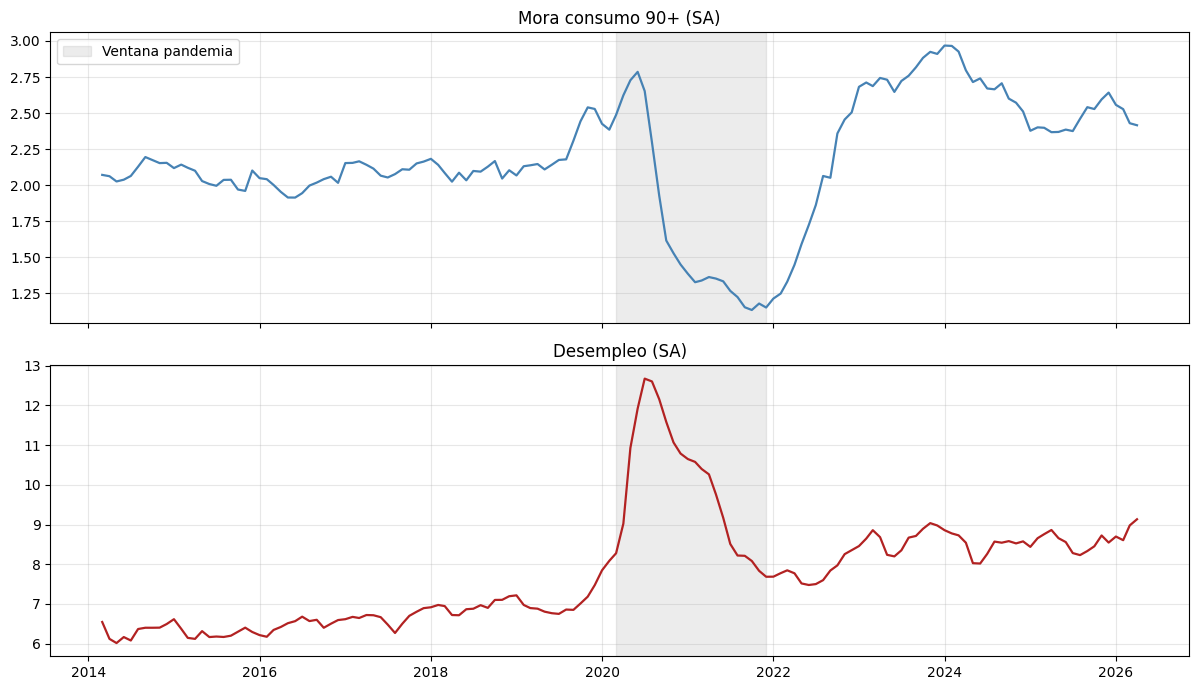

In [54]:
tmp = mora_pivot.sort_values("fecha2").copy()
tmp["fecha2"] = pd.to_datetime(tmp["fecha2"])

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for a, col, tit, c in [
    (ax[0], "Consumo_sa", "Mora consumo 90+ (SA)", "steelblue"),
    (ax[1], "desempleo_sa", "Desempleo (SA)", "firebrick")
]:
    a.plot(tmp["fecha2"], tmp[col], color=c, lw=1.6)
    a.axvspan(PAND_INI, PAND_FIN, color="grey", alpha=0.15, label="Ventana pandemia")
    a.set_title(tit)
    a.grid(alpha=0.3)

ax[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

## 0.5 - serie contigua + dummies

Una vez detectada la anomalía que introdujo la pandemia se creará una variable dummy para dicho periodo. 

In [55]:
# 1) Serie mensual contigua, índice a inicio de mes (MS), tz-naive
idx = pd.to_datetime(mora_pivot["fecha2"])
if getattr(idx.dt, "tz", None) is not None:
    idx = idx.dt.tz_localize(None)
idx = idx.dt.to_period("M").dt.to_timestamp()

df = (mora_pivot.assign(fecha=idx)
      .set_index("fecha")[["Consumo_sa", "desempleo_sa"]]
      .sort_index())

# reindex al rango completo MS y verificar contigüidad ANTES de seguir
full   = pd.date_range(df.index.min(), df.index.max(), freq="MS")
faltan = full.difference(df.index)
dups   = df.index[df.index.duplicated()]
df = df.reindex(full)
df.index.freq = "MS"

print(f"Rango: {df.index.min():%Y-%m} a {df.index.max():%Y-%m}  |  {len(df)} meses")
print(f"Meses faltantes en origen : {len(faltan)}   duplicados: {len(dups)}")
print(f"NaN tras reindex -> Consumo_sa: {df['Consumo_sa'].isna().sum()}  "
      f"desempleo_sa: {df['desempleo_sa'].isna().sum()}")

# 2) Dummy de pandemia (bloque) sobre la ventana de la Parte 1
PAND_INI = pd.Timestamp("2020-03-01")
PAND_FIN = pd.Timestamp("2021-12-01")
df["d_pand"] = ((df.index >= PAND_INI) & (df.index <= PAND_FIN)).astype(int)
print(f"Meses marcados como pandemia: {int(df['d_pand'].sum())}")   # esperado: 22


Rango: 2014-03 a 2026-04  |  146 meses
Meses faltantes en origen : 0   duplicados: 0
NaN tras reindex -> Consumo_sa: 0  desempleo_sa: 0
Meses marcados como pandemia: 22


## 0.6 Harness para Benchmark

Antes de pasar a la siguiente etapa definiremos un backtest para evaluar cada modelo.

In [56]:
# =====================================================================
# HARNESS DE BACKTEST MULTI-HORIZONTE  (agnóstico al modelo)
# Zona de evaluación = últimos 12 meses (post-quiebre); origen deslizante.
# =====================================================================
HORIZONTES = [1, 3, 6, 8, 12]
N_TEST     = 12
TARGET     = "Consumo_sa"

def backtest(nombre, fit_predict_fn, data=df, target=TARGET,
             horizontes=HORIZONTES, n_test=N_TEST):
    """
    fit_predict_fn(train_df, h_max) -> array de longitud h_max con los
    pronósticos de 'target' para o+1 ... o+h_max. 'train_df' = todo hasta el origen.
    """
    y, n = data[target].values, len(data)
    h_max = max(horizontes)
    o_min = (n - n_test) - h_max
    errores = {h: [] for h in horizontes}
    for o in range(o_min, n - 1):
        fc = np.asarray(fit_predict_fn(data.iloc[:o + 1], h_max), dtype=float)
        for h in horizontes:
            t = o + h
            if (t <= n - 1) and (t >= n - n_test):
                errores[h].append(y[t] - fc[h - 1])
    filas = [{"modelo": nombre, "h": h, "n_eval": len(errores[h]),
              "RMSE": np.sqrt(np.mean(np.square(errores[h]))) if errores[h] else np.nan,
              "MAE":  np.mean(np.abs(errores[h]))             if errores[h] else np.nan}
             for h in horizontes]
    return pd.DataFrame(filas), errores

# ---- baseline naïve (random walk): piso de comparación legítimo ----
def rw_fit_predict(train_df, h_max, target=TARGET):
    return np.repeat(train_df[target].iloc[-1], h_max)

resumen_rw, _ = backtest("RandomWalk", rw_fit_predict)
print(resumen_rw.to_string(index=False))
print("\nn_eval = 12 en todos los horizontes:", (resumen_rw["n_eval"] == 12).all())

# ---- consolidador + figura central (se llena cuando tengas los 3 modelos) ----
def comparar(*resumenes):
    tabla = pd.concat(resumenes, ignore_index=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    for mod, g in tabla.groupby("modelo"):
        ax.plot(g["h"], g["RMSE"], marker="o", label=mod)
    ax.set_xlabel("Horizonte (meses)"); ax.set_ylabel("RMSE")
    ax.set_title("Error de pronóstico por horizonte"); ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()
    #return tabla.pivot(index="h", columns="modelo", values="RMSE").round(4)

    modelo  h  n_eval  RMSE   MAE
RandomWalk  1      12 0.057 0.046
RandomWalk  3      12 0.114 0.095
RandomWalk  6      12 0.154 0.137
RandomWalk  8      12 0.187 0.166
RandomWalk 12      12 0.199 0.165

n_eval = 12 en todos los horizontes: True


# 1 - Modelos para Benchmark

Antes de usar como covariante el desempleo se buscará un modelo ARIMAX para usarlo como benchmark. Se busca determinar qué tan bien se puede pronosticar la mora de consumo usando únicamente su propia historia (modelos univariados), para luego evaluar si agregar el desempleo entrega una mejora real y estadísticamente sustantiva.


## 1.1 - Random Walk (benchmark)

En primer lugar se define un Random walk a 12 meses para tener un parámetro de comparación.

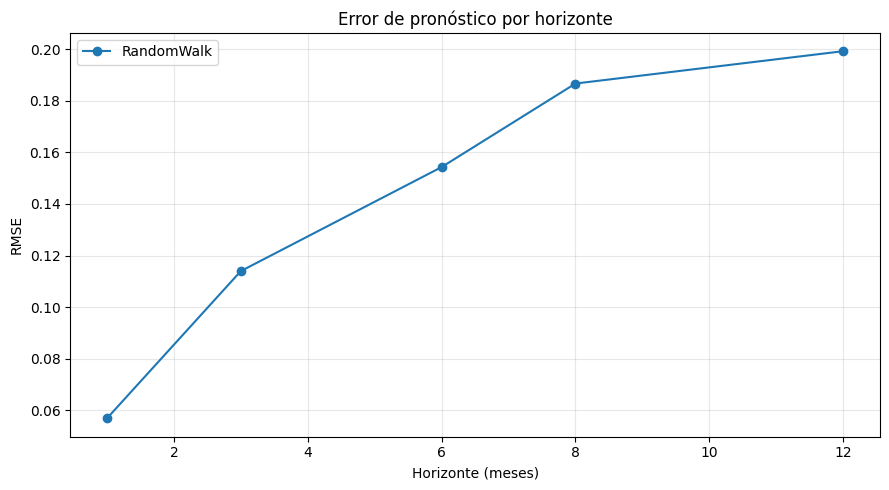

In [57]:
comparar(resumen_rw)   # por ahora solo el naíve; luego sumas ARIMAX y VECM

## 1.2 - Modelos ARIMAX

Buscamos los mejores candidatos para un ARIMAX para la mora consumo, para ello seleccionaremos los candidatos por AICs y se verificará la ausencia de autocorrelación de sus residuos mediante el test  de Ljung-Box.

In [58]:


TARGET = "Consumo_sa"
y   = df[TARGET]
ex  = df[["d_pand"]]                      # dummy de pandemia como regresor exógeno

# --- grilla de órdenes (p,d,q); d=1 fijo porque la serie es I(1) ---
P = range(0, 4); D = [1]; Q = range(0, 4)
filas = []
for p, d, q in itertools.product(P, D, Q):
    if p == 0 and q == 0:
        continue
    try:
        m = SARIMAX(y, exog=ex, order=(p, d, q),
                    trend="n", enforce_stationarity=False,
                    enforce_invertibility=False).fit(disp=False)
        k   = m.params.shape[0]
        n   = m.nobs
        aic = m.aic
        aicc = aic + (2*k*(k+1))/(n-k-1) if n-k-1 > 0 else np.nan
        lb  = acorr_ljungbox(m.resid[d:], lags=[12], return_df=True)["lb_pvalue"].iloc[0]
        rmse_in = np.sqrt(np.mean(m.resid[d:]**2))
        filas.append({"orden": f"({p},{d},{q})", "p": p, "q": q,
                      "AIC": aic, "AICc": aicc, "BIC": m.bic,
                      "loglik": m.llf, "LjungBox_p": lb, "RMSE_in": rmse_in,
                      "converge": m.mle_retvals["converged"]})
    except Exception as e:
        filas.append({"orden": f"({p},{d},{q})", "p": p, "q": q,
                      "AIC": np.nan, "AICc": np.nan, "BIC": np.nan,
                      "loglik": np.nan, "LjungBox_p": np.nan, "RMSE_in": np.nan,
                      "converge": False})

tabla = (pd.DataFrame(filas)
         .sort_values("AICc")
         .reset_index(drop=True))
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(tabla.to_string(index=False))

mejor = tabla.iloc[0]
print(f"\n→ Mejor por AICc: {mejor['orden']}  "
      f"(AICc={mejor['AICc']:.2f}, LjungBox p={mejor['LjungBox_p']:.3f})")
print("  Nota: LjungBox_p > 0.05 = residuos sin autocorrelación (admisible).")

  orden  p  q      AIC     AICc      BIC  loglik  LjungBox_p  RMSE_in  converge
(3,1,2)  3  2 -341.184 -340.372 -320.493 177.592       0.809    0.082      True
(1,1,0)  1  0 -339.899 -339.730 -330.989 172.949       0.347    0.086      True
(0,1,3)  0  3 -339.178 -338.749 -324.434 174.589       0.528    0.069      True
(2,1,3)  2  3 -338.947 -338.135 -318.306 176.473       0.809    0.082      True
(2,1,0)  2  0 -338.290 -338.006 -326.438 173.145       0.211    0.083      True
(2,1,2)  2  2 -337.906 -337.301 -320.171 174.953       0.813    0.103      True
(1,1,3)  1  3 -337.698 -337.094 -320.005 174.849       0.787    0.073      True
(1,1,1)  1  1 -337.349 -337.066 -325.498 172.675       0.594    0.093      True
(1,1,2)  1  2 -336.900 -336.472 -322.121 173.450       0.276    0.082      True
(3,1,3)  3  3 -337.267 -336.216 -313.677 176.633       0.859    0.079     False
(2,1,1)  2  1 -336.369 -335.941 -321.555 173.185       0.168    0.081      True
(3,1,0)  3  0 -333.255 -332.827 -318.476

Para tener mayor claridad se incluye un análisis visual de rezagos y errores móviles.

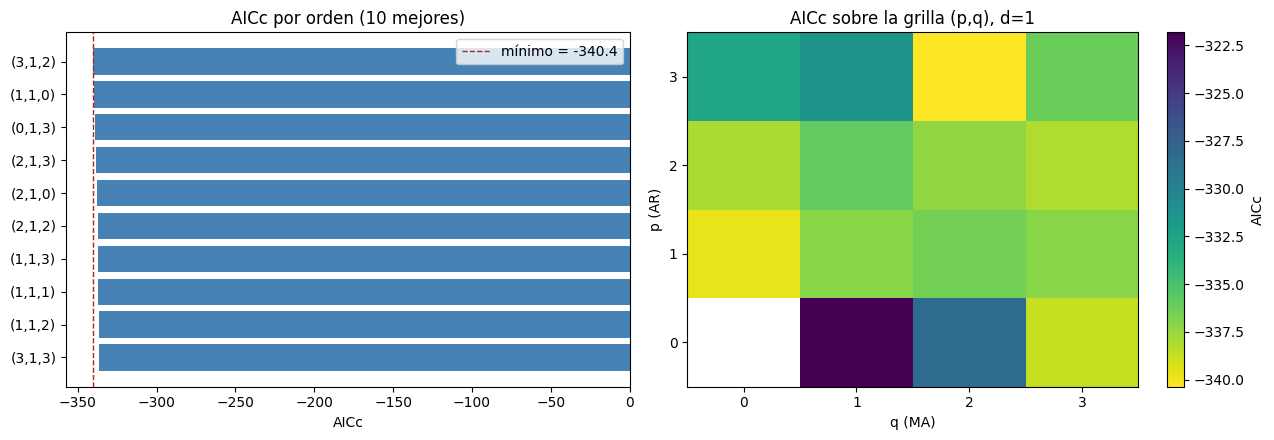

In [59]:
top = tabla.dropna(subset=["AICc"]).head(10)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# panel 1: AICc de los 10 mejores (¿gana por paliza o hay empate?)
ax[0].barh(top["orden"][::-1], top["AICc"][::-1], color="steelblue")
ax[0].set_title("AICc por orden (10 mejores)"); ax[0].set_xlabel("AICc")
ax[0].axvline(top["AICc"].min(), color="firebrick", ls="--", lw=1,
              label=f"mínimo = {top['AICc'].min():.1f}")
ax[0].legend()

# panel 2: mapa de sensibilidad AICc sobre la grilla (p,q)
piv = tabla.pivot(index="p", columns="q", values="AICc")
im = ax[1].imshow(piv, cmap="viridis_r", aspect="auto", origin="lower")
ax[1].set_xticks(range(len(piv.columns))); ax[1].set_xticklabels(piv.columns)
ax[1].set_yticks(range(len(piv.index)));   ax[1].set_yticklabels(piv.index)
ax[1].set_xlabel("q (MA)"); ax[1].set_ylabel("p (AR)")
ax[1].set_title("AICc sobre la grilla (p,q), d=1")
plt.colorbar(im, ax=ax[1], label="AICc")
plt.tight_layout(); plt.show()

Al observar el análisis gráfico de modelos candidatos se opta por entrenar a los siguientes candidatos: 
- (3,1,2)
- (1,1,0) 

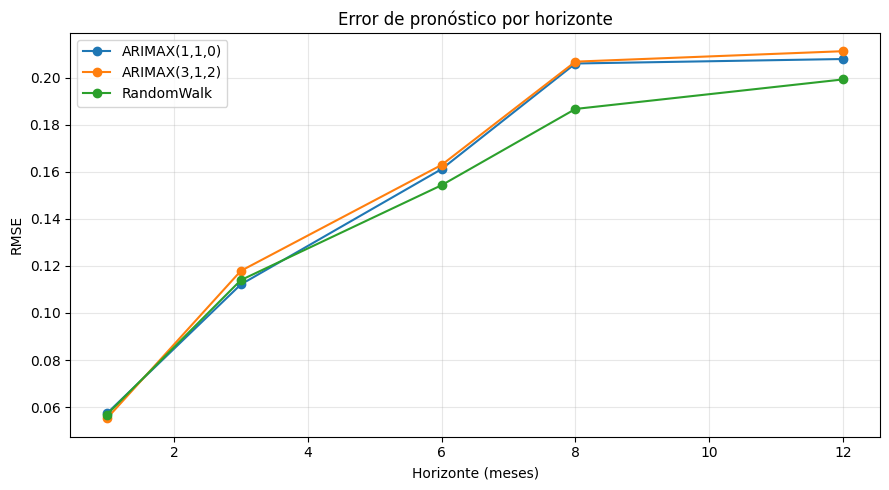

None


In [60]:
from functools import partial
from statsmodels.tsa.statespace.sarimax import SARIMAX

def arimax_fit_predict(train_df, h_max, order, target=TARGET, exog_cols=["d_pand"]):
    m = SARIMAX(train_df[target], exog=train_df[exog_cols], order=order, trend="n",
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    ex_fut = np.zeros((h_max, len(exog_cols)))     # d_pand=0 en toda la zona de test (post-2025)
    return np.asarray(m.forecast(steps=h_max, exog=ex_fut))

resumen_312, _ = backtest("ARIMAX(3,1,2)", partial(arimax_fit_predict, order=(3,1,2)))
resumen_110, _ = backtest("ARIMAX(1,1,0)", partial(arimax_fit_predict, order=(1,1,0)))


print(comparar(resumen_rw, resumen_312, resumen_110))

Ningún candidato le gana al random walk, esto también queda mucho más claro al compararlo con el pronóstico vs el valor real

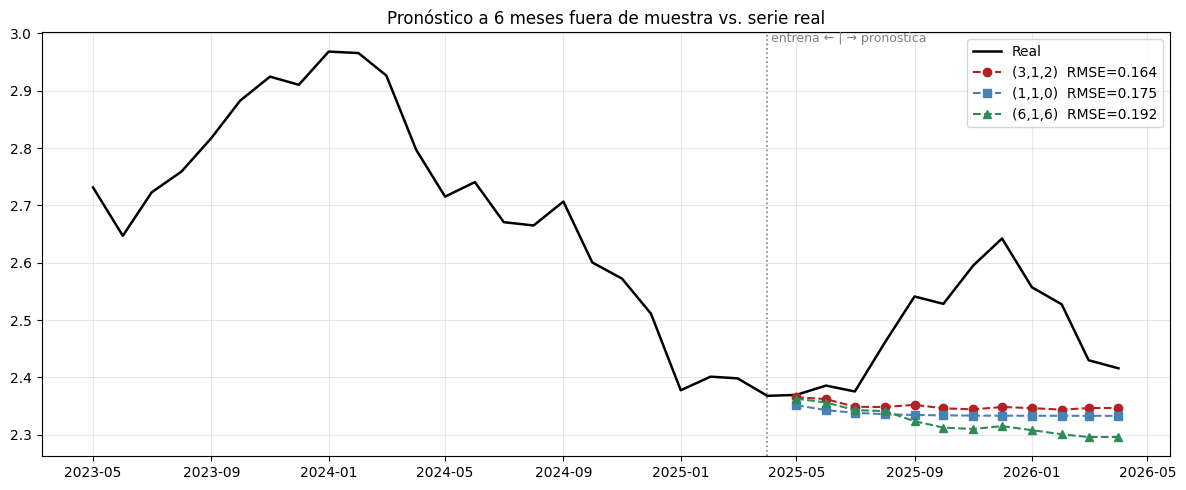

In [61]:
H_VIS = 12
train_vis = df.iloc[:-H_VIS]
fechas_fc = df.index[-H_VIS:]
real      = df[TARGET]

fc_312 = arimax_fit_predict(train_vis, H_VIS, order=(3,1,2))
fc_110 = arimax_fit_predict(train_vis, H_VIS, order=(1,1,0))
fc_616 = arimax_fit_predict(train_vis, H_VIS, order=(6,1,6))          # nuevo
rmse = lambda f: np.sqrt(np.mean((real.iloc[-H_VIS:].values - f)**2))

fig, ax = plt.subplots(figsize=(12, 5))
zoom = real.iloc[-36:]
ax.plot(zoom.index, zoom.values, color="black", lw=1.8, label="Real")
ax.plot(fechas_fc, fc_312, color="firebrick",  marker="o", ls="--",
        label=f"(3,1,2)  RMSE={rmse(fc_312):.3f}")
ax.plot(fechas_fc, fc_110, color="steelblue", marker="s", ls="--",
        label=f"(1,1,0)  RMSE={rmse(fc_110):.3f}")
ax.plot(fechas_fc, fc_616, color="seagreen",  marker="^", ls="--",   # nuevo
        label=f"(6,1,6)  RMSE={rmse(fc_616):.3f}")
ax.axvline(train_vis.index[-1], color="grey", ls=":", lw=1.2)
ax.text(train_vis.index[-1], ax.get_ylim()[1], " entrena ← | → pronostica",
        va="top", fontsize=9, color="grey")
ax.set_title("Pronóstico a 6 meses fuera de muestra vs. serie real")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

# 2 - Relación largo plazo

En esta sección formalizaremos la relación a largo plazo entre desempleo y mora 90+(%) consumo. Se buscará un sistema VECM, el cual al no ser viable se reemplazará por el componente ECM 


## 2.1 Gregory-Hansen

En primer lugar se reproduce el resultado de cointegración obtenido en la parte 1

In [62]:
LAG = 8   # lag óptimo de la Parte 1

# --- 1) Gregory-Hansen modelo C sobre la muestra limpia (idéntico a Parte 1) ---
gh_stat, pos, _ = gregory_hansen(clean_opt["Consumo_sa"], clean_opt["dlag"], model="C")
BREAK = clean_opt["fecha2"].iloc[pos]
print(f"GH(C) = {gh_stat:.3f}  vs 5% = {GH_CRIT['C']['5%']}   quiebre = {BREAK:%Y-%m}")

# --- 2) regresión cointegrante en la muestra limpia -> coeficientes de largo plazo ---
phi_clean = (clean_opt["fecha2"] >= BREAK).astype(float)
Xc = sm.add_constant(pd.DataFrame({"phi": phi_clean, "dlag": clean_opt["dlag"]}))
lr = sm.OLS(clean_opt["Consumo_sa"], Xc).fit()
c0, lam, beta = lr.params["const"], lr.params["phi"], lr.params["dlag"]
print(f"\nLargo plazo:  const={c0:.4f}   quiebre(λ)={lam:.4f}   elasticidad(β)={beta:.4f}")

GH(C) = -6.239  vs 5% = -4.61   quiebre = 2024-04

Largo plazo:  const=-0.3083   quiebre(λ)=-0.3374   elasticidad(β)=0.3702


## 2.2 Johansen

 Aplicamos el test de Johansen para determinar el rango de cointegración del bivariado (desempleo, mora).  En su definición, Johansen, a diferencia de Gregory-Hansen, considera una relación constante por lo que podría fallar ante la existencia del quiebre en 2024-04.

In [63]:
# --- 1) selección de rezagos del VAR/VECM (constante restringida a la cointegración) ---
sel = select_order(df[["Consumo_sa", "desempleo_sa"]].astype(float), maxlags=12, deterministic="ci")
print(sel.summary())
print("\nSugeridos ->  AIC:", sel.aic, " BIC:", sel.bic,
      " HQIC:", sel.hqic, " FPE:", sel.fpe)

# --- 2) test de Johansen: rango de cointegración ---
# k_ar_diff = nº de diferencias rezagadas. Si el summary de arriba reporta el orden p
# del VAR en niveles, entonces k_ar_diff = p - 1. Ajusta tras leer el summary.
k_ar_diff = max(int(sel.aic) - 1, 1)

for metodo in ["trace", "maxeig"]:
    r = select_coint_rank(df[["Consumo_sa", "desempleo_sa"]].astype(float), det_order=0, k_ar_diff=k_ar_diff,
                          method=metodo, signif=0.05)
    print(f"\n=== Johansen ({metodo}), k_ar_diff={k_ar_diff} ===")
    print(r.summary())
    print("Rango de cointegración estimado:", r.rank)

 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -7.665      -7.492   0.0004688      -7.595
1       -8.322     -8.061*   0.0002432      -8.216
2       -8.336      -7.989   0.0002397      -8.195
3       -8.395      -7.961   0.0002260      -8.219
4      -8.449*      -7.927  0.0002143*     -8.237*
5       -8.430      -7.821   0.0002186      -8.183
6       -8.443      -7.748   0.0002159      -8.161
7       -8.391      -7.609   0.0002277      -8.073
8       -8.358      -7.489   0.0002355      -8.005
9       -8.322      -7.365   0.0002447      -7.933
10      -8.324      -7.281   0.0002446      -7.900
11      -8.276      -7.146   0.0002571      -7.817
12      -8.306      -7.089   0.0002503      -7.811
--------------------------------------------------

Sugeridos ->  AIC: 4  BIC: 1  HQIC: 4  FPE: 4

=== Johansen (trace), k_ar_diff=3 ===
Johansen cointegration test using trace test st

Se observa que Johansen no encuentra relación de largo plazo, por lo que el modelo VECM no parece viable, pero es necesario recordar que Johansen asume una relación constante y en la parte 1 se encontró cointegración con un quiebre en 2024-04. Además los shocks introducidos por la pandemia podrían estar afectando el resultado,  por lo que es conveniente hacer un análisis más profundo analizando especificaciones controladas con pandemia y sin controlar.

In [64]:
sys_raw = df[["Consumo_sa", "desempleo_sa"]].astype(float)

# --- serie con la pandemia controlada: residualizamos cada variable sobre d_pand ---
X = sm.add_constant(df[["d_pand"]].astype(float))
sys_ctrl = pd.DataFrame(
    {c: sm.OLS(sys_raw[c], X).fit().resid for c in sys_raw.columns},
    index=sys_raw.index)

def sweep(data, etiqueta):
    filas = []
    for det in [-1, 0, 1]:
        for k in range(1, 7):
            fila = {"serie": etiqueta, "det_order": det, "k_ar_diff": k}
            for metodo in ["trace", "maxeig"]:
                try:
                    r = select_coint_rank(data, det_order=det, k_ar_diff=k,
                                          method=metodo, signif=0.05)
                    fila[metodo] = r.rank
                except Exception:
                    fila[metodo] = np.nan
            filas.append(fila)
    return pd.DataFrame(filas)

res = pd.concat([sweep(sys_raw,  "cruda (pandemia adentro)"),
                 sweep(sys_ctrl, "controlada por d_pand")], ignore_index=True)

print(res.to_string(index=False))

# --- veredicto ---
print("\n" + "="*60)
for etq, g in res.groupby("serie", sort=False):
    n = len(g) * 2
    n1 = int((g[["trace", "maxeig"]] == 1).sum().sum())
    print(f"{etq:28s}: rango=1 en {n1}/{n} especificaciones "
          f"({'ROBUSTO r=0' if n1 == 0 else 'SENSIBLE a la especificación'})")
print("="*60)

                   serie  det_order  k_ar_diff  trace  maxeig
cruda (pandemia adentro)         -1          1      0       0
cruda (pandemia adentro)         -1          2      0       0
cruda (pandemia adentro)         -1          3      0       0
cruda (pandemia adentro)         -1          4      0       0
cruda (pandemia adentro)         -1          5      0       0
cruda (pandemia adentro)         -1          6      0       0
cruda (pandemia adentro)          0          1      2       0
cruda (pandemia adentro)          0          2      0       0
cruda (pandemia adentro)          0          3      0       0
cruda (pandemia adentro)          0          4      0       0
cruda (pandemia adentro)          0          5      0       0
cruda (pandemia adentro)          0          6      0       0
cruda (pandemia adentro)          1          1      2       2
cruda (pandemia adentro)          1          2      2       2
cruda (pandemia adentro)          1          3      2       0
cruda (p

Tras hacer una búsqueda más exhaustiva se observa que los datos muestran sensibilidad al periodo de pandemia,  además, sumado al hecho de que mediante Gregory-Hansen se encontró una cointegración a largo plazo, se procederá a la creación de un VECM forzado

In [65]:
BREAK   = pd.Timestamp("2024-04-01")
d_break = (df.index >= BREAK).astype(float).reshape(-1, 1)   # quiebre de nivel
#d_break = (df.index >= BREAK).astype(float).values.reshape(-1, 1)   # quiebre de nivel
d_pand  = df[["d_pand"]].astype(float).values                       # pandemia

# --- elegimos k_ar_diff por residuos blancos, no por AIC ---
for k in [1, 2, 3, 4, 5, 6,7,8]:
    try:
        m = VECM(sys_raw, k_ar_diff=k, coint_rank=1, deterministic="ci",
                 exog=d_pand, exog_coint=d_break).fit()
        lb = [acorr_ljungbox(m.resid[:, j], lags=[12], return_df=True)["lb_pvalue"].iloc[0]
              for j in range(2)]
        print(f"k_ar_diff={k}:  LjungBox p (mora)={lb[0]:.3f}  (desempleo)={lb[1]:.3f}   "
              f"{'residuos limpios ✅' if min(lb) > 0.05 else 'autocorrelación ⚠️'}")
    except Exception as e:
        print(f"k_ar_diff={k}: falló -> {type(e).__name__}")

k_ar_diff=1:  LjungBox p (mora)=0.036  (desempleo)=0.794   autocorrelación ⚠️
k_ar_diff=2:  LjungBox p (mora)=0.086  (desempleo)=0.615   residuos limpios ✅
k_ar_diff=3:  LjungBox p (mora)=0.051  (desempleo)=0.777   residuos limpios ✅
k_ar_diff=4:  LjungBox p (mora)=0.041  (desempleo)=0.990   autocorrelación ⚠️
k_ar_diff=5:  LjungBox p (mora)=0.105  (desempleo)=0.996   residuos limpios ✅
k_ar_diff=6:  LjungBox p (mora)=0.633  (desempleo)=0.991   residuos limpios ✅
k_ar_diff=7:  LjungBox p (mora)=0.737  (desempleo)=0.981   residuos limpios ✅
k_ar_diff=8:  LjungBox p (mora)=0.851  (desempleo)=0.977   residuos limpios ✅


## 2.3 - VECM forzado

 Si bien los resultados de Johansen sugieren que no existe una relación de cointegración, estimaremos un VECM forzado con rango de cointegración igual a 1. El objetivo de este ejercicio es documentar la falla e identificar inconsistencias con la teoría principal de este trabajo "El desempleo es un predictor de  la Mora consumo 90+(%)"

In [66]:
K = 8   # ← reemplaza por el k elegido arriba

vecm = VECM(sys_raw, k_ar_diff=K, coint_rank=1, deterministic="ci",
            exog=d_pand, exog_coint=d_break).fit()

print(vecm.summary())

# --- las dos lecturas que importan ---
print("\nβ (vector cointegrante, normalizado en mora):")
print(pd.Series(vecm.beta[:, 0] / vecm.beta[0, 0],
                index=["Consumo_sa", "desempleo_sa"]).round(4))

print("\nα (velocidad de ajuste) y su p-valor:")
alpha = vecm.alpha[:, 0]
pvals = vecm.pvalues_alpha[:, 0]
res_alpha = pd.DataFrame(
    {"alpha": alpha.round(4), "p_value": pvals.round(4)},
    index=["Consumo_sa", "desempleo_sa"]
)
print(res_alpha)

# --- media vida del ajuste (solo tiene sentido para Consumo_sa) ---
hl_mora = np.log(0.5) / np.log(1 + alpha[0])
print(f"\nMedia vida del ajuste de la mora (Consumo_sa): {hl_mora:.2f} meses")


Det. terms outside the coint. relation & lagged endog. parameters for equation Consumo_sa
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
exog1              -0.0564      0.029     -1.965      0.049      -0.113      -0.000
L1.Consumo_sa       0.3046      0.084      3.615      0.000       0.139       0.470
L1.desempleo_sa     0.0411      0.029      1.400      0.161      -0.016       0.099
L2.Consumo_sa       0.1419      0.096      1.479      0.139      -0.046       0.330
L2.desempleo_sa    -0.0031      0.034     -0.090      0.928      -0.070       0.064
L3.Consumo_sa       0.0148      0.095      0.156      0.876      -0.171       0.201
L3.desempleo_sa    -0.0900      0.034     -2.629      0.009      -0.157      -0.023
L4.Consumo_sa      -0.1854      0.093     -1.989      0.047      -0.368      -0.003
L4.desempleo_sa    -0.0092      0.035     -0.260      0.795      -0.07

Al revisar los resultados del VECM impuesto, a primera vista estos parecen coherentes; sin embargo, es importante considerar que:

- El modelo fue estimado imponiendo un rango de cointegración igual a 1, pese a que el test de Johansen sugiere un rango de 0.

- La vida media de ajuste de la mora supera los 30 meses, lo que no parece consistente con una relación de cointegración entre mora de consumo y desempleo con un rezago de 8 meses.

Dado lo anterior, en el siguiente paso se evaluará la robustez de la dinámica de ajuste y de la elasticidad de largo plazo ante cambios en el número de rezagos del VECM impuesto.

In [67]:
def resumen_vecm(k):
    m = VECM(sys_raw, k_ar_diff=k, coint_rank=1, deterministic="ci",
             exog=d_pand, exog_coint=d_break).fit()
    beta = m.beta[:, 0] / m.beta[0, 0]
    return {"k": k,
            "beta_desempleo": beta[1],
            "alpha_mora": m.alpha[0, 0], "p_mora": m.pvalues_alpha[0, 0],
            "alpha_des":  m.alpha[1, 0], "p_des":  m.pvalues_alpha[1, 0]}

tab = pd.DataFrame([resumen_vecm(k) for k in [2, 3, 5, 6,7,8]])
print(tab.round(4).to_string(index=False))

# medias vidas implícitas (solo válidas si α es significativo y del signo correcto)
tab["hl_mora"] = np.log(0.5) / np.log(1 + tab["alpha_mora"])
print("\nMedia vida del ajuste de la mora (meses):")
print(tab[["k", "alpha_mora", "p_mora", "hl_mora"]].round(3).to_string(index=False))

 k  beta_desempleo  alpha_mora  p_mora  alpha_des  p_des
 2          -0.296      -0.024   0.164      0.235  0.000
 3          -0.285      -0.020   0.247      0.242  0.000
 5          -0.412      -0.020   0.167      0.199  0.000
 6          -0.385      -0.029   0.045      0.208  0.000
 7          -0.442      -0.025   0.071      0.192  0.000
 8          -0.483      -0.023   0.074      0.175  0.000

Media vida del ajuste de la mora (meses):
 k  alpha_mora  p_mora  hl_mora
 2      -0.024   0.164   28.064
 3      -0.020   0.247   34.621
 5      -0.020   0.167   34.995
 6      -0.029   0.045   23.215
 7      -0.025   0.071   27.834
 8      -0.023   0.074   30.154


Al revisar el cálculo del VECM con distintos rezagos, se observa que:

- Si bien el coeficiente 
𝛼
α para la mora es negativo, solo se acerca a ser significativo a partir del rezago 6.

- La vida media de ajuste de la mora varía entre 23 y 30 meses, un valor llamativamente alto.

- La elasticidad de largo plazo respecto al desempleo oscila entre −0.28 y −0.48, distinta del −0.37 encontrado en la Parte 1.

Por lo anterior, se descarta el VECM con rango impuesto y se procederá a formular un ECM que utilice el componente de corrección de error (ECT) para predecir la mora 90+ (%) de consumo en función del desempleo.

## 2.4 ECT

En este paso, construiremos el componente ECT, para ello usaremos el rezago 8 encontrado en la parte 1

In [68]:
LAG = 8   # lag óptimo de la Parte 1
# --- 3) ECT evaluado sobre la serie CONTIGUA completa ---
des_lag  = df["desempleo_sa"].shift(LAG)
phi_full = (df.index >= BREAK).astype(float)
df["ECT"] = df["Consumo_sa"] - c0 - lam * phi_full - beta * des_lag

# --- 4) ¿el ECT es I(0)? condición necesaria para que el ECM tenga sentido ---
ect = df["ECT"].dropna()
adf = adfuller(ect, regression="c", autolag="AIC")
print(f"ADF sobre ECT: stat={adf[0]:.3f}  p={adf[1]:.4f}  n={len(ect)}  "
      f"{'estacionario ✅' if adf[1] < 0.05 else 'NO estacionario ⚠️'}")

ADF sobre ECT: stat=-2.399  p=0.1421  n=138  NO estacionario ⚠️


Se observa que este resultado es no estacionario, pero como ya se hace costumbre, esto podría estar relacionado con el periodo de pandemia. A continuación se analiza gráficamente el ECT para determinar si este se vio afectado por el periodo de pandemia.

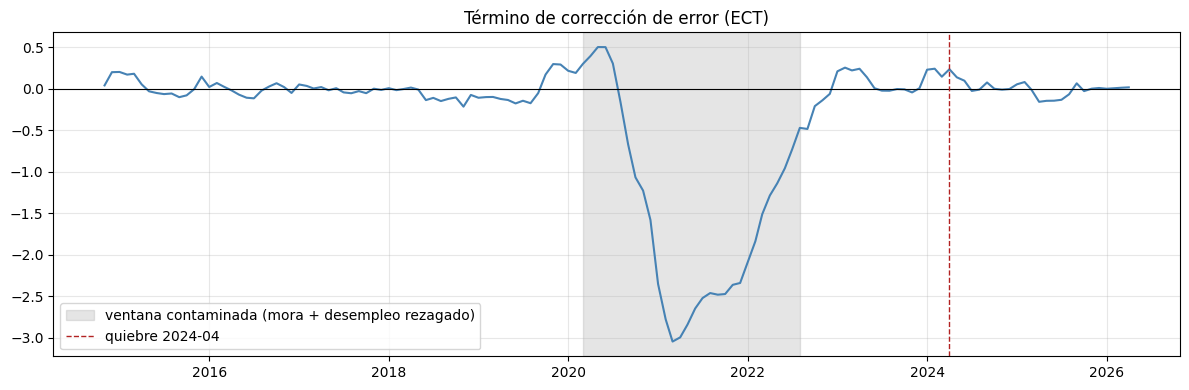

In [69]:
# --- A) ver dónde está la contaminación ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["ECT"], color="steelblue", lw=1.5)
ax.axhline(0, color="black", lw=0.8)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2022-08-01"),
           color="grey", alpha=0.2, label="ventana contaminada (mora + desempleo rezagado)")
ax.axvline(BREAK, color="firebrick", ls="--", lw=1, label="quiebre 2024-04")
ax.set_title("Término de corrección de error (ECT)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Del gráfico anterior y junto al resultado del ADF del ECT se concluye que la pandemia significó un shock que afectó al ECT, por lo que a continuación se procederá a recalcular el ADF excluyendo los meses de pandemia.

## 2.5 ECT - Sin Pandemia

In [70]:
# --- B) ADF sobre el ECT excluyendo la ventana contaminada (lógica de la Parte 1) ---
CONT_INI, CONT_FIN = pd.Timestamp("2020-03-01"), pd.Timestamp("2022-08-01")
mask_ok = ~df.index.to_series().between(CONT_INI, CONT_FIN)
ect_ok = df.loc[mask_ok, "ECT"].dropna()
a = adfuller(ect_ok, regression="c", autolag="AIC")
print(f"ADF ECT sin ventana contaminada: stat={a[0]:.3f}  p={a[1]:.4f}  n={len(ect_ok)}  "
      f"{'estacionario ✅' if a[1] < 0.05 else 'NO estacionario ⚠️'}")


ADF ECT sin ventana contaminada: stat=-6.218  p=0.0000  n=108  estacionario ✅


Al repetir el test ADF se encuentra que el ECT es no estacionario. En el siguiente bloque se recalcula el ECT excluyendo los meses de pandemia.

In [71]:
# --- C) ECT purgado: dummy de pandemia DENTRO de la regresión de largo plazo,
#        estimada sobre la serie contigua (así el ECT queda definido en todos los meses) ---
des_lag  = df["desempleo_sa"].shift(LAG)
phi_full = (df.index >= BREAK).astype(float)
dP = df.index.to_series().between(CONT_INI, CONT_FIN).astype(float)   # ventana ampliada

X2 = sm.add_constant(pd.DataFrame({"phi": phi_full, "dP": dP, "dlag": des_lag},
                                  index=df.index)).dropna()
y2 = df.loc[X2.index, "Consumo_sa"]
lr2 = sm.OLS(y2, X2).fit()
print(lr2.params.round(4).to_string())

print(f"β purgado = {lr2.params['dlag']:.4f}   (Parte 1: 0.3702)")

const    2.554
phi      0.358
dP      -0.485
dlag    -0.044
β purgado = -0.0441   (Parte 1: 0.3702)


Ahora, con el ECT limpio, se procede a crear el ECM

## 2.6 - Construcción del ECM uniecuacional

In [72]:
d = pd.DataFrame(index=df.index)
d["dy"]     = df["Consumo_sa"].diff()
d["ECT_1"]  = df["ECT"].shift(1)
d["d_pand"] = df["d_pand"].astype(float)
for i in [1, 2]:
    d[f"dy_{i}"] = d["dy"].shift(i)
for j in [0, 1, 2]:                       # Δdesempleo rezagado LAG+j
    d[f"dx_{LAG+j}"] = df["desempleo_sa"].diff().shift(LAG + j)

d = d.dropna()
X = sm.add_constant(d.drop(columns="dy"))
ecm = sm.OLS(d["dy"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(ecm.summary())

g, p = ecm.params["ECT_1"], ecm.pvalues["ECT_1"]
print(f"\nγ (velocidad de ajuste) = {g:.4f}   p = {p:.4f}   n = {int(ecm.nobs)}")
if -1 < g < 0:
    print(f"Media vida del ajuste   = {np.log(0.5)/np.log(1+g):.1f} meses")
else:
    print("γ fuera de (-1,0): no hay corrección de error estable.")

                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     26.46
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           4.50e-22
Time:                        19:16:47   Log-Likelihood:                 168.02
No. Observations:                 135   AIC:                            -320.0
Df Residuals:                     127   BIC:                            -296.8
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0027      0.004      0.737      0.4

Este ECM parece más sensato que el VECM forzado, pero aún mantiene una vida media demasiado larga, 23 meses, por lo que se optará por desarrollar una versión más parsimoniosa utilizando la elasticidad a largo plazo detectada en la parte 1.

## 2.7 ECM final

In [73]:
CONT_INI, CONT_FIN = pd.Timestamp("2020-03-01"), pd.Timestamp("2022-08-01")

# --- diseño sobre calendario contiguo (los rezagos se calculan bien) ---
d = pd.DataFrame(index=df.index)
d["dy"]    = df["Consumo_sa"].diff()
d["ECT_1"] = df["ECT"].shift(1)          # ECT de la Parte 1 (β=0.3702) — el que es I(0)
d["dy_1"]  = d["dy"].shift(1)
d["dy_2"]  = d["dy"].shift(2)

# --- máscara: descartar filas cuyos INSUMOS caen en la ventana contaminada ---
bad    = df.index.to_series().between(CONT_INI, CONT_FIN)
bad_dy = bad | bad.shift(1, fill_value=True)          # Δy_t usa niveles t y t-1
valid  = (~bad
          & ~bad.shift(1, fill_value=True)            # ECT_{t-1}
          & ~bad_dy.shift(1, fill_value=True)         # Δy_{t-1}
          & ~bad_dy.shift(2, fill_value=True))        # Δy_{t-2}

d = d[valid].dropna()
print(f"n = {len(d)}   pre: {(d.index < CONT_INI).sum()}   post: {(d.index > CONT_FIN).sum()}")

X   = sm.add_constant(d.drop(columns="dy"))
ecm_2 = sm.OLS(d["dy"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(ecm_2.summary())

g, p = ecm_2.params["ECT_1"], ecm_2.pvalues["ECT_1"]
print(f"\nγ = {g:.4f}   p = {p:.4f}   n = {int(ecm_2.nobs)}")
if -1 < g < 0:
    print(f"Media vida del ajuste = {np.log(0.5)/np.log(1+g):.1f} meses")
else:
    print("γ fuera de (-1,0): no hay corrección de error estable.")
    

n = 104   pre: 63   post: 41
                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     20.67
Date:                Thu, 23 Jul 2026   Prob (F-statistic):           1.69e-10
Time:                        19:16:47   Log-Likelihood:                 157.05
No. Observations:                 104   AIC:                            -306.1
Df Residuals:                     100   BIC:                            -295.5
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011  

Este nuevo ECM tiene una vida media más razonable, ahora es conveniente revisar si la vida media se mantiene constante antes y después del periodo (omitido) de la pandemia

In [74]:
d["post"] = (d.index > CONT_FIN).astype(float)
d["ECT_1_post"] = d["ECT_1"] * d["post"]
X2 = sm.add_constant(d.drop(columns="dy"))
ecm2 = sm.OLS(d["dy"], X2).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(f"\nγ pre  = {ecm2.params['ECT_1']:.4f}")
print(f"Δγ post = {ecm2.params['ECT_1_post']:.4f}   p = {ecm2.pvalues['ECT_1_post']:.4f}")


γ pre  = -0.1760
Δγ post = 0.0012   p = 0.9822


Se observa que la velocidad de ajuste es muy similar antes y después del periodo de pandemia. Antes de cerrar esta sección se decidirá qué modelo ECM se usará como definitivo, para ello se compararán ambos modelos

In [75]:
print("Comparación de especificaciones del ECM:\n")
for nombre, mod in [("ECM con dummy pandemia (2.6)", ecm),
                    ("ECM con exclusión (2.7, FINAL)", ecm_2)]:
    g = mod.params["ECT_1"]
    mv = np.log(0.5)/np.log(1+g) if -1 < g < 0 else float("nan")
    print(f"  {nombre:32s}:  γ = {g:+.4f}   p = {mod.pvalues['ECT_1']:.4f}   "
          f"media vida = {mv:.1f} meses")


Comparación de especificaciones del ECM:

  ECM con dummy pandemia (2.6)    :  γ = -0.0300   p = 0.0312   media vida = 22.7 meses
  ECM con exclusión (2.7, FINAL)  :  γ = -0.1731   p = 0.0000   media vida = 3.6 meses


El ECM con dummy arroja una media vida de ~23 meses, incompatible con el
lead de 8 meses: la dummy de bloque no absorbe la forma de U de la excursión
pandémica y distorsiona el ajuste. La exclusión aritmética lo evita.

# 3 - Evaluación predictiva

 Una vez determinado el ECM se procede a la evaluación mediante back test, a la estimación de valores futuros de morosidad y a presentar una herramienta que nos permita levantar alertas sobre posibles cambios estructurales que puedan afectar la validez de nuestro modelo

## 3.1 - ECM al harness (escenario oráculo)

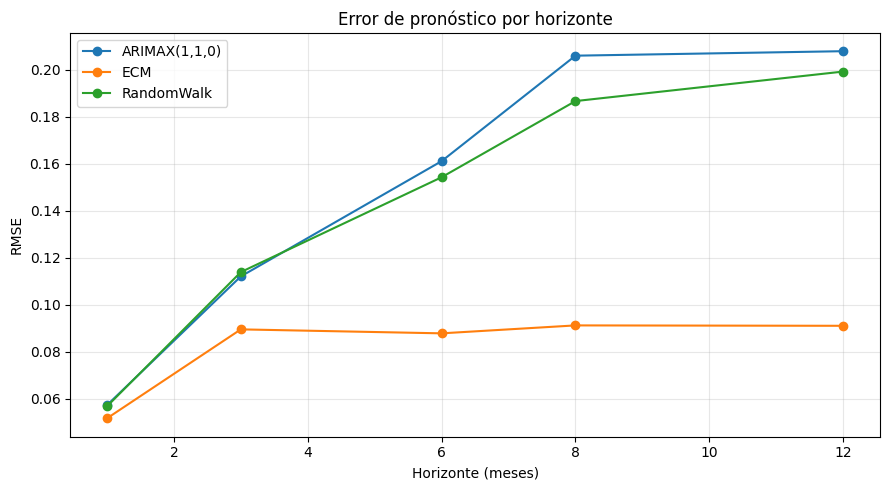

None


In [76]:
def ecm_fit_predict(train_df, h_max, target=TARGET):
    # 1) reestimar el ECM solo con lo que el origen conoce
    d = pd.DataFrame(index=train_df.index)
    d["dy"]    = train_df[target].diff()
    d["ECT_1"] = train_df["ECT"].shift(1)
    d["dy_1"]  = d["dy"].shift(1)
    d["dy_2"]  = d["dy"].shift(2)

    bad    = train_df.index.to_series().between(CONT_INI, CONT_FIN)
    bad_dy = bad | bad.shift(1, fill_value=True)
    valid  = (~bad & ~bad.shift(1, fill_value=True)
              & ~bad_dy.shift(1, fill_value=True) & ~bad_dy.shift(2, fill_value=True))
    dd = d[valid].dropna()
    m  = sm.OLS(dd["dy"], sm.add_constant(dd.drop(columns="dy"))).fit()
    c_, g_, t1_, t2_ = (m.params["const"], m.params["ECT_1"],
                        m.params["dy_1"], m.params["dy_2"])

    # 2) forecast recursivo
    des = train_df["desempleo_sa"]
    ultimo_des = des.iloc[-1]
    hist   = list(train_df[target].values)
    fechas = list(train_df.index)
    out = []
    for k in range(h_max):
        f_lag   = fechas[-1] - pd.DateOffset(months=LAG)
        des_val = des.loc[f_lag] if f_lag in des.index else ultimo_des   # flat si no observado
        phi     = float(fechas[-1] >= BREAK)
        ect_prev = hist[-1] - c0 - lam*phi - beta*des_val
        dy1, dy2 = hist[-1]-hist[-2], hist[-2]-hist[-3]
        nueva = hist[-1] + (c_ + g_*ect_prev + t1_*dy1 + t2_*dy2)
        out.append(nueva)
        hist.append(nueva); fechas.append(fechas[-1] + pd.DateOffset(months=1))
    return np.array(out)

resumen_ecm, _ = backtest("ECM", ecm_fit_predict)
print(comparar(resumen_rw, resumen_110, resumen_ecm))

En el backtest, el ECM le gana tanto al Random Walk como al ARIMAX(1,1,0): un 54% mejor que el Random Walk a 12 meses. Pero este resultado, sospechosamente bueno, tiene una trampa: el ECM se construyó usando el quiebre estructural de abril 2024 ya identificado, con parámetros estimados sobre toda la muestra. Es decir, para pronosticar el pasado, el modelo usó información del futuro.

Eso deja una pregunta:

- ¿Qué habría pronosticado un analista situado *justo después* del quiebre, que todavía no podía saber que ese quiebre existía?

Para responderla, reestimamos el test de Gregory-Hansen en cada origen del backtest —usando solo los datos disponibles hasta ese momento— y reconstruimos el pronóstico con el vector cointegrante (quiebre incluido) que el analista habría tenido en cada fecha. Si el buen resultado depende de conocer el quiebre por adelantado, este ejercicio lo revelará.

## 3.2 - Gregory-Hansen reestimado en cada origen

In [77]:
def gh_en_origen(train_df, lag=8, model="C"):
    """Reestima Gregory-Hansen usando SOLO datos hasta el final de train_df."""
    b = train_df[["Consumo_sa", "desempleo_sa"]].copy()
    b["dlag"]  = b["desempleo_sa"].shift(lag)
    b["fpred"] = b.index - pd.DateOffset(months=lag)
    en_pand = (b.index.to_series().between(PAND_INI, PAND_FIN)
               | b["fpred"].between(PAND_INI, PAND_FIN))
    cl = b[~en_pand].dropna(subset=["dlag"])
    if len(cl) < 40:
        return None
    gh, pos, _ = gregory_hansen(cl["Consumo_sa"], cl["dlag"], model=model)
    brk = cl.index[pos]
    phi = (cl.index >= brk).astype(float)
    X   = sm.add_constant(pd.DataFrame({"phi": phi, "dlag": cl["dlag"].values}, index=cl.index))
    lr  = sm.OLS(cl["Consumo_sa"], X).fit()
    return {"c0": lr.params["const"], "lam": lr.params["phi"], "beta": lr.params["dlag"],
            "break": brk, "gh": gh, "rechaza": gh < GH_CRIT[model]["5%"], "n": len(cl)}

# --- diagnóstico: qué habría visto un analista en cada origen del backtest ---
n, h_max, n_test = len(df), 12, 12
origenes = df.index[(n - n_test) - h_max : n - 1]

filas = []
for o in origenes:
    g = gh_en_origen(df.loc[:o])
    if g:
        filas.append({"origen": o.strftime("%Y-%m"), "GH": round(g["gh"], 2),
                      "rechaza": "sí" if g["rechaza"] else "NO",
                      "quiebre": g["break"].strftime("%Y-%m"),
                      "beta": round(g["beta"], 3), "lam": round(g["lam"], 3)})
diag = pd.DataFrame(filas)
print(diag.to_string(index=False))
print(f"\nCon muestra completa: quiebre=2024-04, beta=0.370, lam=-0.337, GH=-6.24")

 origen     GH rechaza quiebre  beta    lam
2024-05 -7.230      sí 2019-12 0.221  0.273
2024-06 -7.150      sí 2019-12 0.212  0.280
2024-07 -6.980      sí 2019-12 0.198  0.293
2024-08 -6.790      sí 2019-12 0.187  0.302
2024-09 -6.780      sí 2019-12 0.181  0.306
2024-10 -6.400      sí 2019-12 0.174  0.310
2024-11 -6.050      sí 2019-12 0.167  0.314
2024-12 -5.710      sí 2019-12 0.162  0.314
2025-01 -4.880      sí 2022-09 0.183  0.256
2025-02 -4.790      sí 2022-09 0.188  0.240
2025-03 -4.920      sí 2024-01 0.335 -0.123
2025-04 -5.040      sí 2024-02 0.349 -0.197
2025-05 -5.060      sí 2024-02 0.349 -0.213
2025-06 -5.910      sí 2024-04 0.370 -0.328
2025-07 -5.900      sí 2024-04 0.371 -0.338
2025-08 -5.970      sí 2024-04 0.371 -0.342
2025-09 -6.120      sí 2024-04 0.370 -0.338
2025-10 -6.050      sí 2024-04 0.370 -0.339
2025-11 -6.090      sí 2024-06 0.359 -0.337
2025-12 -6.130      sí 2024-06 0.359 -0.336
2026-01 -6.160      sí 2024-06 0.359 -0.335
2026-02 -6.190      sí 2024-06 0

Tal como se temía, el quiebre estructural de 2024-04 es detectado recién en junio de 2025, 14 meses después, por lo que en dicha fecha se podría haber desarrollado un ECM que incluyese dicho quiebre estructural.

Cabe destacar que a partir de 2025-11 el cambio estructural de abril 2024 se traslada a junio de 2024, lo que se explica por una oscilación, por ruido, del mismo quiebre en ±2 meses.

A continuación realizaremos un back test "honesto" que considere el vector cointegrante disponible en cada momento en que se hubiese desarrollado cada predicción.

## 3.3 - ECM honesto al harness (tiempo real)

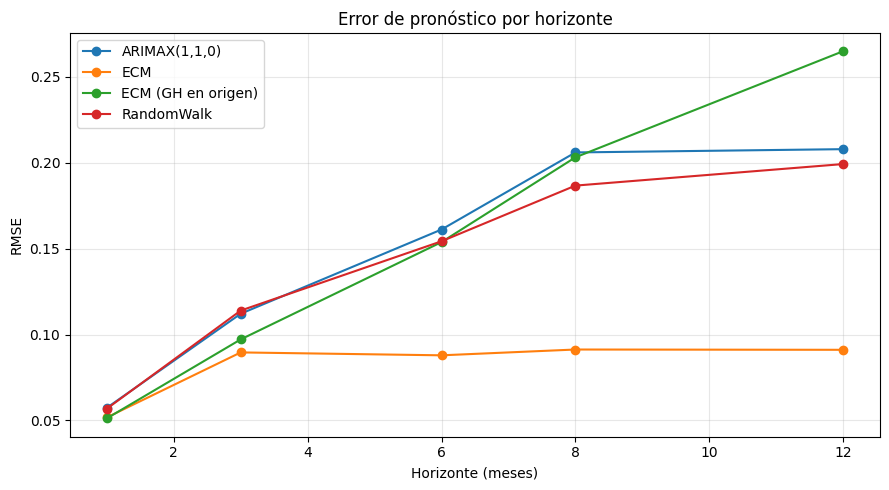

None


In [78]:
def ecm_gh_fit_predict(train_df, h_max, target=TARGET):
    g = gh_en_origen(train_df)
    if g is None:
        return np.repeat(train_df[target].iloc[-1], h_max)      # fallback RW

    # ECT con los parámetros ESTIMADOS EN ESTE ORIGEN
    des_lag = train_df["desempleo_sa"].shift(LAG)
    phi     = (train_df.index >= g["break"]).astype(float)
    ect     = train_df[target] - g["c0"] - g["lam"]*phi - g["beta"]*des_lag

    d = pd.DataFrame(index=train_df.index)
    d["dy"]    = train_df[target].diff()
    d["ECT_1"] = ect.shift(1)
    d["dy_1"]  = d["dy"].shift(1)
    d["dy_2"]  = d["dy"].shift(2)
    bad    = train_df.index.to_series().between(CONT_INI, CONT_FIN)
    bad_dy = bad | bad.shift(1, fill_value=True)
    valid  = (~bad & ~bad.shift(1, fill_value=True)
              & ~bad_dy.shift(1, fill_value=True) & ~bad_dy.shift(2, fill_value=True))
    dd = d[valid].dropna()
    if len(dd) < 30:
        return np.repeat(train_df[target].iloc[-1], h_max)
    m = sm.OLS(dd["dy"], sm.add_constant(dd.drop(columns="dy"))).fit()
    c_, g_, t1_, t2_ = (m.params["const"], m.params["ECT_1"],
                        m.params["dy_1"], m.params["dy_2"])

    des, ultimo_des = train_df["desempleo_sa"], train_df["desempleo_sa"].iloc[-1]
    corte  = train_df.index[-1]
    hist   = list(train_df[target].values)
    fechas = list(train_df.index)
    out = []
    for k in range(h_max):
        f_lag   = fechas[-1] - pd.DateOffset(months=LAG)
        des_val = des.loc[f_lag] if (f_lag <= corte and f_lag in des.index) else ultimo_des
        ect_prev = hist[-1] - g["c0"] - g["lam"]*float(fechas[-1] >= g["break"]) - g["beta"]*des_val
        nueva = hist[-1] + (c_ + g_*ect_prev + t1_*(hist[-1]-hist[-2]) + t2_*(hist[-2]-hist[-3]))
        out.append(nueva); hist.append(nueva)
        fechas.append(fechas[-1] + pd.DateOffset(months=1))
    return np.array(out)

resumen_ecm_gh, _ = backtest("ECM (GH en origen)", ecm_gh_fit_predict)
print(comparar(resumen_rw, resumen_110, resumen_ecm, resumen_ecm_gh))

Ahora, al realizar el backtest honesto se observa que para un rango mayor de meses, el ECM con Gregory-Hansen en el origen no habría sido capaz de ganarle al random walk. 

Lo anterior no invalida el ECM, solo limita el margen de observaciones que pueden utilizarse para hacer un back test honesto. En la siguiente sección se harán una serie de back test usando datos a partir del cambio estructural de 2024-04

## 3.4 - Backtest de ventanas fijas (chequeo)

Dada la limitación del quiebre estructural de 2024-04 se harán una serie de backtest a partir de 2024-05 en ventanas de 6 meses (o hasta donde se alcance para las observaciones más recientes), además se incluirá un gráfico que muestre dichas predicciones

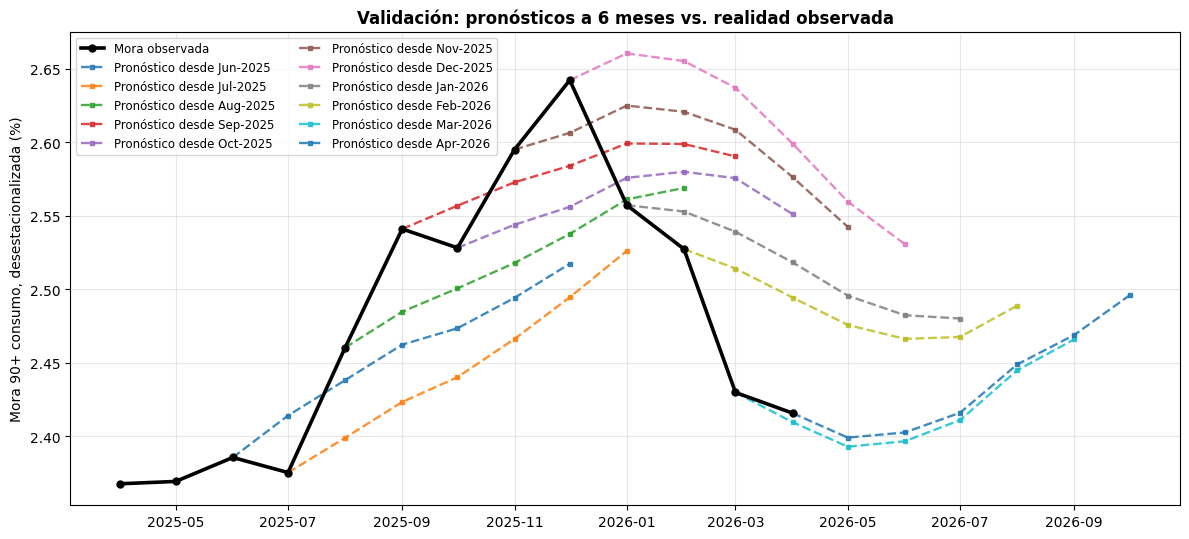

RMSE por ventana (solo meses con dato observado):
  desde 2025-06: 0.0784   (6 meses evaluados)
  desde 2025-07: 0.1038   (6 meses evaluados)
  desde 2025-08: 0.0613   (6 meses evaluados)
  desde 2025-09: 0.0789   (6 meses evaluados)
  desde 2025-10: 0.0937   (6 meses evaluados)
  desde 2025-11: 0.1202   (5 meses evaluados)
  desde 2025-12: 0.1609   (4 meses evaluados)
  desde 2026-01: 0.0878   (3 meses evaluados)
  desde 2026-02: 0.0815   (2 meses evaluados)
  desde 2026-03: 0.0061   (1 meses evaluados)
  promedio: 0.0872
  promedio (ventanas con ≥4 meses): 0.0996


In [94]:
# ===== VALIDACIÓN VISUAL: pronósticos rodantes de 6 meses (post-detección) =====
ORIGENES = pd.date_range("2025-06-01", "2026-04-01", freq="MS")
H = 6

def pronostico_6m(origen, h=H):
    """Reestima el ECM hasta 'origen' y pronostica h meses. Devuelve Serie indexada."""
    d = pd.DataFrame(index=df.index)
    d["dy"]    = df["Consumo_sa"].diff()
    d["ECT_1"] = df["ECT"].shift(1)
    d["dy_1"]  = d["dy"].shift(1)
    d["dy_2"]  = d["dy"].shift(2)

    bad    = df.index.to_series().between(CONT_INI, CONT_FIN)
    bad_dy = bad | bad.shift(1, fill_value=True)
    valid  = (~bad & ~bad.shift(1, fill_value=True)
              & ~bad_dy.shift(1, fill_value=True) & ~bad_dy.shift(2, fill_value=True)
              & (d.index <= origen))
    dd = d[valid].dropna()
    m  = sm.OLS(dd["dy"], sm.add_constant(dd.drop(columns="dy"))).fit()
    c_, g_, t1_, t2_ = (m.params["const"], m.params["ECT_1"],
                        m.params["dy_1"], m.params["dy_2"])

    hist   = list(df.loc[:origen, "Consumo_sa"].values)
    fechas = list(df.loc[:origen].index)
    out    = []
    for k in range(h):
        f_lag    = fechas[-1] - pd.DateOffset(months=LAG)
        des_val  = df.loc[f_lag, "desempleo_sa"]
        phi      = float(fechas[-1] >= BREAK)
        ect_prev = hist[-1] - c0 - lam*phi - beta*des_val
        nueva    = hist[-1] + (c_ + g_*ect_prev
                               + t1_*(hist[-1]-hist[-2]) + t2_*(hist[-2]-hist[-3]))
        out.append(nueva); hist.append(nueva)
        fechas.append(fechas[-1] + pd.DateOffset(months=1))
    return pd.Series(out, index=fechas[-h:])

# --- gráfico ---
fig, ax = plt.subplots(figsize=(12, 5.5))
real = df["Consumo_sa"].loc["2025-04":]
ax.plot(real.index, real.values, color="black", lw=2.6, marker="o", ms=5,
        label="Mora observada", zorder=10)

errores = []
for o in ORIGENES:
    p = pronostico_6m(o)

    # --- calcular error ANTES de anclar (el ancla es dato real, error 0) ---
    obs = p.index.intersection(df.index)
    if len(obs) > 0:
        e = np.sqrt(np.mean((df.loc[obs, "Consumo_sa"] - p.loc[obs])**2))
        errores.append((o, e, len(obs)))

    # --- anclar al último observado, solo para el gráfico ---
    p = pd.concat([pd.Series([df.loc[o, "Consumo_sa"]], index=[o]), p])
    ax.plot(p.index, p.values, lw=1.7, ls="--", marker="s", ms=3.5, alpha=0.85,
            label=f"Pronóstico desde {o:%b-%Y}")



ax.set_ylabel("Mora 90+ consumo, desestacionalizada (%)")
ax.set_title("Validación: pronósticos a 6 meses vs. realidad observada",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8.5, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("RMSE por ventana (solo meses con dato observado):")
for o, e, n in errores:
    print(f"  desde {o:%Y-%m}: {e:.4f}   ({n} meses evaluados)")
if errores:
    print(f"  promedio: {np.mean([e for _, e, _ in errores]):.4f}")
    val = [e for _, e, n in errores if n >= 4]
    print(f"  promedio (ventanas con ≥4 meses): {np.mean(val):.4f}")




Al mirar en conjunto el gráfico como los distintos RMSE, se observa que el modelo ECM presenta dificultades para detectar cambios de pendiente, esto último se refleja en el RMSE de diciembre 2025 que es el más alto del horizonte estudiado y se produce justo en el punto de inflección.

# 4 - Vigilancia: monitoreo del modelo (CUSUM)

Debido a la alerta que generó el backtest usando Gregory-Hansen en el origen, el cual tardó 14 meses en detectar un quiebre, queda planteada la siguiente pregunta:
- ¿Cómo podemos tener una alerta temprana ante un cambio estructural?

En esta sección se creará una función CUSUM que servirá como monitoreo preventivo.

## 4.1 - CUSUM retrospectivo (detección en 5 meses)

En primer lugar simularemos un CUSUM a partir de abril 2024 para simular en cuánto tiempo nos alertaría de un posible quiebre estructural.

In [80]:
# ECT calculado SIN el dummy de quiebre = lo que un analista tenía antes de abril-2024
pre = df.loc[:"2024-03"]
cl  = pre[~pre.index.to_series().between(PAND_INI, PAND_FIN)].dropna(subset=["desempleo_sa"])
X   = sm.add_constant(cl["desempleo_sa"].shift(LAG).dropna())
y   = cl.loc[X.index, "Consumo_sa"]
lr_pre = sm.OLS(y, X).fit()

ect_sin_quiebre = (df["Consumo_sa"]
                   - lr_pre.params["const"]
                   - lr_pre.params["desempleo_sa"] * df["desempleo_sa"].shift(LAG))

# referencia: media y sigma en régimen estable pre-quiebre
ref = ect_sin_quiebre.loc["2022-09":"2024-03"]
mu, sd = ref.mean(), ref.std()

# --- CUSUM tabular (k = holgura en sigmas, h = umbral) ---
k, h = 0.5, 5.0
z = (ect_sin_quiebre.loc["2024-04":] - mu) / sd
Sp = Sm = 0.0
for t, zt in z.items():
    Sp = max(0, Sp + zt - k)
    Sm = max(0, Sm - zt - k)
    if max(Sp, Sm) > h:
        print(f"🚨 CUSUM dispara en {t:%Y-%m}  "
              f"({(t.year-2024)*12 + t.month-4} meses después del quiebre)")
        break
    print(f"{t:%Y-%m}  S+={Sp:5.4f}  S-={Sm:5.4f}")

2024-04  S+=0.0000  S-=0.1159
2024-05  S+=0.0000  S-=0.7399
2024-06  S+=0.0000  S-=1.5469
2024-07  S+=0.0000  S-=2.9775
2024-08  S+=0.0000  S-=4.3343
🚨 CUSUM dispara en 2024-09  (5 meses después del quiebre)


Se observa que a los 5 meses el CUSUM hubiese dado la alerta. En el siguiente bloque se construirá un CUSUM operativo para el monitoreo mes a mes.

## 4.2 - CUSUM operacional (¿alarma hoy?)

In [81]:
# ===============================================================
# CUSUM OPERACIONAL — modelo congelado en 2025-06, monitoreo forward
# ===============================================================
# parámetros del origen 2025-06 de tu tabla diagnóstica
C0_F, LAM_F, BETA_F = -0.3083, -0.328, 0.370
BRK_F = pd.Timestamp("2024-04-01")

des_lag = df["desempleo_sa"].shift(LAG)
phi_f   = (df.index >= BRK_F).astype(float)
ect_f   = df["Consumo_sa"] - C0_F - LAM_F*phi_f - BETA_F*des_lag

# escala de referencia: sd del ECT en régimen limpio
ref    = ect_f[~ect_f.index.to_series().between(CONT_INI, CONT_FIN)].dropna()
sd_ref = ref.std()
print(f"sd de referencia: {sd_ref:.4f}   (μ=0 por construcción del modelo)")

k, h = 0.5, 5.0
z = ect_f.loc["2025-07":] / sd_ref
Sp = Sm = 0.0
print(f"\n{'mes':<9}{'ECT':>8}{'z':>7}{'S+':>7}{'S-':>7}   estado")
alarma = False
for t, zt in z.items():
    Sp, Sm = max(0, Sp + zt - k), max(0, Sm - zt - k)
    if max(Sp, Sm) > h: alarma = True
    print(f"{t:%Y-%m}{ect_f[t]:>8.3f}{zt:>7.2f}{Sp:>7.2f}{Sm:>7.2f}   "
          f"{'🚨 ALARMA' if max(Sp,Sm) > h else 'ok'}")

print(f"\n→ {'ALARMA ACTIVA ⚠️' if alarma else 'Sin alarma — el modelo sigue calibrado ✅'}")

sd de referencia: 0.1254   (μ=0 por construcción del modelo)

mes           ECT      z     S+     S-   estado
2025-07  -0.142  -1.13   0.00   0.63   ok
2025-08  -0.076  -0.61   0.00   0.74   ok
2025-09   0.056   0.44   0.00   0.00   ok
2025-10  -0.038  -0.30   0.00   0.00   ok
2025-11  -0.009  -0.07   0.00   0.00   ok
2025-12  -0.000  -0.00   0.00   0.00   ok
2026-01  -0.009  -0.08   0.00   0.00   ok
2026-02  -0.003  -0.02   0.00   0.00   ok
2026-03   0.002   0.02   0.00   0.00   ok
2026-04   0.007   0.06   0.00   0.00   ok

→ Sin alarma — el modelo sigue calibrado ✅


Al revisar el CUSUM operativo, observamos que no se han levantado alertas

# 5 - Entregables

En esta sección se consolida todo lo anterior y se formulan los entregables finales de este proyecto.

En primer lugar se definirá formalmente el modelo ECM que se usará para pronósticos.

In [82]:
# ===== PARÁMETROS DEL MODELO FINAL (consolidados) =====
# --- largo plazo (Gregory-Hansen) --- ya deberían existir: c0, lam, beta, BREAK, LAG
# --- corto plazo (ECM) ---
const = ecm_2.params["const"]
gamma = ecm_2.params["ECT_1"]
th1   = ecm_2.params["dy_1"]
th2   = ecm_2.params["dy_2"]

print("LARGO PLAZO (Gregory-Hansen):")
print(f"  c0    = {c0:+.4f}")
print(f"  lam   = {lam:+.4f}   (quiebre {BREAK:%Y-%m})")
print(f"  beta  = {beta:+.4f}   ← elasticidad, debe ser ~0.3702")
print(f"  LAG   = {LAG}")
print("\nCORTO PLAZO (ECM):")
print(f"  const = {const:+.4f}")
print(f"  gamma = {gamma:+.4f}   ← debe ser ~-0.1731")
print(f"  th1   = {th1:+.4f}")
print(f"  th2   = {th2:+.4f}")
print(f"\nMedia vida = {np.log(0.5)/np.log(1+gamma):.1f} meses")

LARGO PLAZO (Gregory-Hansen):
  c0    = -0.3083
  lam   = -0.3374   (quiebre 2024-04)
  beta  = +0.3702   ← elasticidad, debe ser ~0.3702
  LAG   = 8

CORTO PLAZO (ECM):
  const = +0.0011
  gamma = -0.1731   ← debe ser ~-0.1731
  th1   = +0.1579
  th2   = +0.1336

Media vida = 3.6 meses


## 5.1 - Función impulso-respuesta (IRF)

Mediante la función IRF veremos cuánto se demora en transmitirse un cambio en el desempleo a la mora 90+(%)

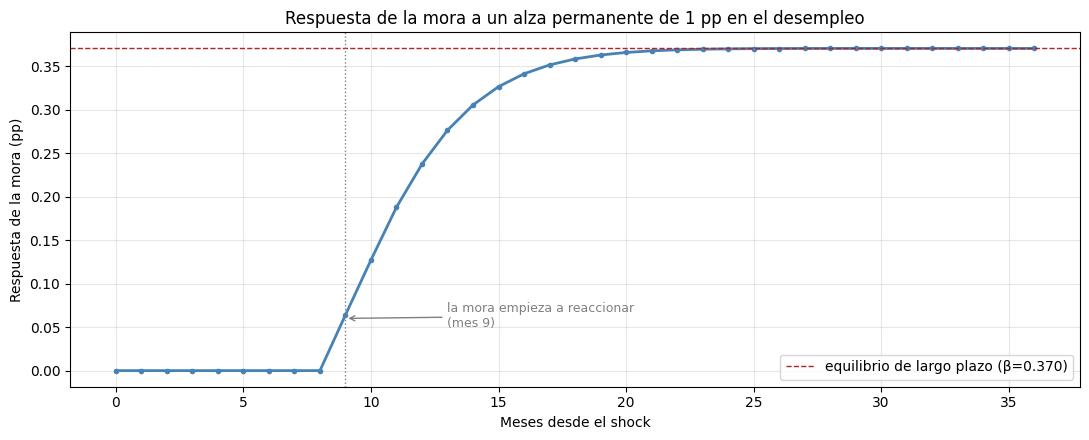

50% del efecto: mes 11   90%: mes 16   asíntota: 0.3702


In [83]:
def irf(h_max=36, shock=1.0):
    """Respuesta de la mora a un shock PERMANENTE de +1pp de desempleo. mes 0 = shock."""
    y = np.zeros(h_max + 1)
    for t in range(1, h_max + 1):
        eq_prev  = beta*shock if (t - 1 - LAG) >= 0 else 0.0
        ect_prev = y[t-1] - eq_prev
        d1 = y[t-1] - y[t-2] if t >= 2 else 0.0
        d2 = y[t-2] - y[t-3] if t >= 3 else 0.0
        y[t] = y[t-1] + gamma*ect_prev + th1*d1 + th2*d2
    return y

r = irf(36)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(range(37), r, color="steelblue", lw=2, marker="o", ms=3)
ax.axhline(beta, color="firebrick", ls="--", lw=1, label=f"equilibrio de largo plazo (β={beta:.3f})")
ax.axvline(9, color="grey", ls=":", lw=1)
ax.annotate("la mora empieza a reaccionar\n(mes 9)", xy=(9, 0.06), xytext=(13, 0.05),
            arrowprops=dict(arrowstyle="->", color="grey"), fontsize=9, color="grey")
ax.set_xlabel("Meses desde el shock"); ax.set_ylabel("Respuesta de la mora (pp)")
ax.set_title("Respuesta de la mora a un alza permanente de 1 pp en el desempleo")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

print(f"50% del efecto: mes {int(np.argmax(r >= 0.5*beta))}   "
      f"90%: mes {int(np.argmax(r >= 0.9*beta))}   asíntota: {r[-1]:.4f}")

Se observa que al mes 11 se transmite a la mora el 50% del efecto del cambio en desempleo, eso es coherente con la vida media estimada previamente de 3,6 meses más los 8 meses de rezago de la cointegración encontrada en la parte 1.

## 5.2 - Pronóstico condicional con bandas

A continuación se realiza el pronóstico para los próximos seis meses

            central   p05   p95
2026-05-01    2.399 2.300 2.492
2026-06-01    2.404 2.282 2.534
2026-07-01    2.417 2.269 2.573
2026-08-01    2.449 2.288 2.616
2026-09-01    2.468 2.300 2.643
2026-10-01    2.497 2.324 2.671
2026-11-01    2.511 2.335 2.687
2026-12-01    2.549 2.365 2.725


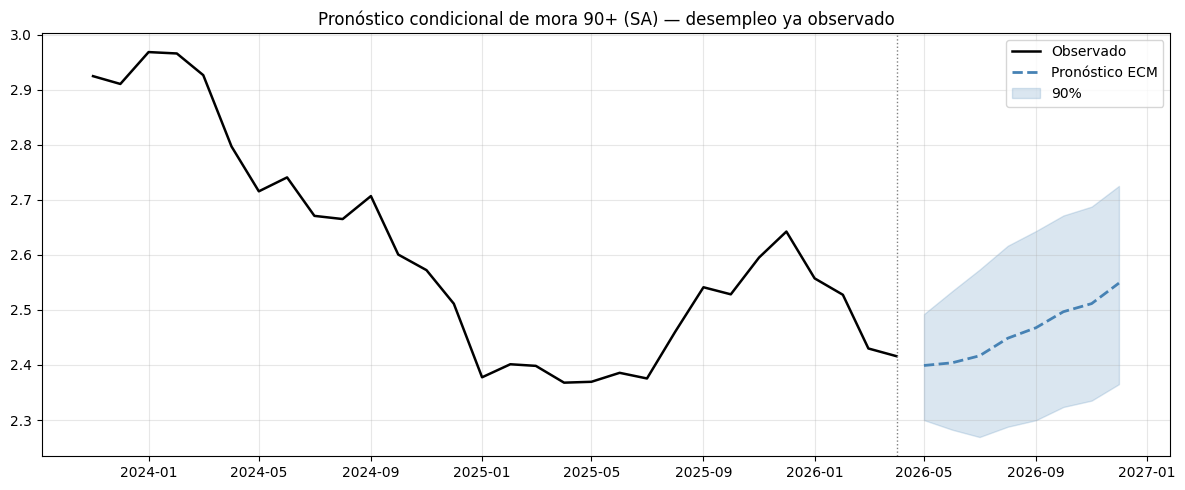

In [84]:
def forecast_bandas(h=8, n_sim=3000, seed=7):
    resid = ecm_2.resid.values                      # residuos del ECM final
    rng   = np.random.default_rng(seed)
    des, corte = df["desempleo_sa"], df.index[-1]
    paths = np.zeros((n_sim, h))

    for s in range(n_sim):
        hist   = list(df["Consumo_sa"].values[-3:])
        fechas = list(df.index[-3:])
        for k in range(h):
            f_lag   = fechas[-1] - pd.DateOffset(months=LAG)
            des_val = des.loc[f_lag] if (f_lag <= corte and f_lag in des.index) else des.iloc[-1]
            ect_prev = hist[-1] - c0 - lam*float(fechas[-1] >= BREAK) - beta*des_val
            eps   = rng.choice(resid)             # bootstrap
            nueva = hist[-1] + (const + gamma*ect_prev
                                + th1*(hist[-1]-hist[-2]) + th2*(hist[-2]-hist[-3])) + eps
            paths[s, k] = nueva
            hist.append(nueva); fechas.append(fechas[-1] + pd.DateOffset(months=1))
    return paths

paths  = forecast_bandas(8)
fechas_f = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=8, freq="MS")
band = pd.DataFrame({
    "central": paths.mean(axis=0),
    "p05":     np.percentile(paths, 5,  axis=0),
    "p95":     np.percentile(paths, 95, axis=0)}, index=fechas_f)
print(band.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
hist_plot = df["Consumo_sa"].iloc[-30:]
ax.plot(hist_plot.index, hist_plot.values, color="black", lw=1.8, label="Observado")
ax.plot(band.index, band["central"], color="steelblue", lw=2, ls="--", label="Pronóstico ECM")
ax.fill_between(band.index, band["p05"], band["p95"], color="steelblue", alpha=0.2, label="90%")
ax.axvline(df.index[-1], color="grey", ls=":", lw=1)
ax.set_title("Pronóstico condicional de mora 90+ (SA) — desempleo ya observado")
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

Se observa que para los próximos 6 meses se espera una morosidad al alza, pero se debe tener en cuenta que este pronóstico es de la mora 90+(%) desestacionalizada, en las siguientes celdas se hará una reestacionalización para tener un pronóstico más certero.

## 5.3 - Deterioro ya comprometido (el techo)

In [85]:
# ===== DETERIORO YA COMPROMETIDO (el "techo" del pronóstico) =====
ult_des   = df["desempleo_sa"].iloc[-1]
mora_hoy  = df["Consumo_sa"].iloc[-1]
eq_impl   = c0 + lam*1 + beta*ult_des          # equilibrio que implica el desempleo YA observado
gap       = eq_impl - mora_hoy
pred_dic  = band["central"].iloc[-1]

print(f"Desempleo observado ({df.index[-1]:%Y-%m}) : {ult_des:.3f}%")
print(f"Equilibrio de mora que implica    : {eq_impl:.3f}")
print(f"Mora actual                       : {mora_hoy:.3f}")
print(f"→ Deterioro YA comprometido       : {gap:+.3f} pp")
print(f"Pronóstico a 8 meses              : {pred_dic:.3f}  "
      f"({100*(pred_dic-mora_hoy)/gap:.0f}% del camino)")
print(f"→ Sigue llegando después del hz.  : {eq_impl-pred_dic:+.3f} pp")

Desempleo observado (2026-04) : 9.132%
Equilibrio de mora que implica    : 2.735
Mora actual                       : 2.416
→ Deterioro YA comprometido       : +0.319 pp
Pronóstico a 8 meses              : 2.549  (42% del camino)
→ Sigue llegando después del hz.  : +0.187 pp


## 5.4 - Re-estacionalización y trampa del trimestre

            central   p05   p95  factor  Δ_sa  Δ_cruda
2026-05-01    2.451 2.352 2.544   0.052   NaN      NaN
2026-06-01    2.446 2.324 2.576   0.042 0.005   -0.005
2026-07-01    2.440 2.293 2.597   0.024 0.013   -0.005
2026-08-01    2.389 2.228 2.557  -0.060 0.032   -0.052
2026-09-01    2.410 2.242 2.586  -0.057 0.019    0.022
2026-10-01    2.434 2.261 2.609  -0.063 0.029    0.024
2026-11-01    2.457 2.281 2.633  -0.054 0.015    0.023
2026-12-01    2.528 2.344 2.705  -0.021 0.037    0.071

⚠️  Meses donde la mora reportada MEJORA mientras el deterioro real EMPEORA:
            central  Δ_sa  Δ_cruda
2026-06-01    2.446 0.005   -0.005
2026-07-01    2.440 0.013   -0.005
2026-08-01    2.389 0.032   -0.052


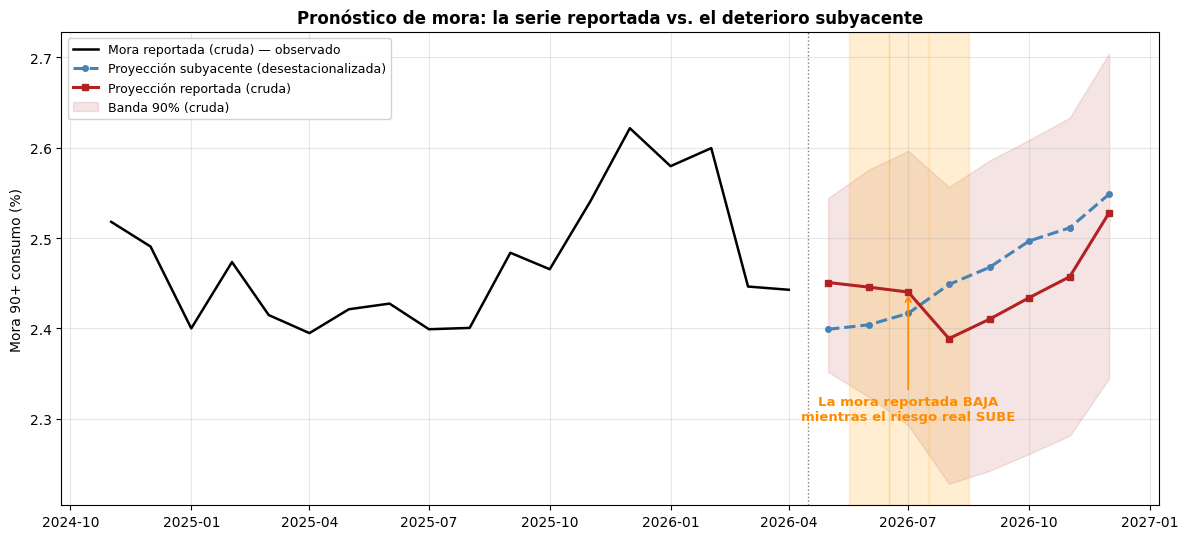

In [86]:
# ===== PRONÓSTICO EN MORA CRUDA (la que se reporta) =====
S["seas_mora"] = S["Consumo"] - S["Consumo_sa"]
perfil = S.groupby(S.index.month)["seas_mora"].mean()

factores   = np.array([perfil[m] for m in band.index.month])
band_cruda = band.add(factores, axis=0)
band_cruda["factor"] = factores
band_cruda["Δ_sa"]   = band["central"].diff()
band_cruda["Δ_cruda"] = band_cruda["central"].diff()
print(band_cruda.round(3).to_string())

# ¿hay meses donde la cruda BAJA mientras la SA SUBE?
trampa = band_cruda[(band_cruda["Δ_sa"] > 0) & (band_cruda["Δ_cruda"] < 0)]
if len(trampa):
    print("\n⚠️  Meses donde la mora reportada MEJORA mientras el deterioro real EMPEORA:")
    print(trampa[["central", "Δ_sa", "Δ_cruda"]].round(3).to_string())

# Grafico 
fig, ax = plt.subplots(figsize=(12, 5.5))

# histórico reciente en crudo (últimos ~18 meses)
hist_cruda = S["Consumo"].iloc[-18:]
ax.plot(hist_cruda.index, hist_cruda.values, color="black", lw=1.8,
        label="Mora reportada (cruda) — observado")

# las dos proyecciones
ax.plot(band.index, band["central"], color="steelblue", lw=2.2, ls="--",
        marker="o", ms=4, label="Proyección subyacente (desestacionalizada)")
ax.plot(band_cruda.index, band_cruda["central"], color="firebrick", lw=2.2,
        marker="s", ms=4, label="Proyección reportada (cruda)")

# banda de incertidumbre sobre la cruda (la que se reporta)
ax.fill_between(band_cruda.index, band_cruda["p05"], band_cruda["p95"],
                color="firebrick", alpha=0.12, label="Banda 90% (cruda)")

# --- sombrear los meses trampa: sa sube, cruda baja ---
d_sa    = band["central"].diff()
d_cruda = band_cruda["central"].diff()
trampa  = (d_sa > 0) & (d_cruda < 0)
for idx in band.index[trampa]:
    ax.axvspan(idx - pd.Timedelta(days=15), idx + pd.Timedelta(days=15),
               color="orange", alpha=0.18)

# anotación de la trampa
mes_trampa = band.index[trampa]
if len(mes_trampa):
    x_ann = mes_trampa[len(mes_trampa)//2]
    ax.annotate("La mora reportada BAJA\nmientras el riesgo real SUBE",
                xy=(x_ann, band_cruda.loc[x_ann, "central"]),
                xytext=(x_ann, band_cruda["central"].min() - 0.09),
                ha="center", fontsize=9.5, color="darkorange", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.3))

ax.axvline(band.index[0] - pd.Timedelta(days=15), color="grey", ls=":", lw=1)
ax.set_ylabel("Mora 90+ consumo (%)")
ax.set_title("Pronóstico de mora: la serie reportada vs. el deterioro subyacente",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones

Este trabajo muestra un procedimiento para pronosticar la mora 90+ del sistema bancario chileno. La metodología es completamente replicable a carteras internas de cualquier institución que otorgue productos de crédito.

El resultado principal es que la mora de consumo debiera seguir aumentando gradualmente en 2026, empujada por el deterioro del desempleo ya observado. Para leer bien esa señal, es clave trabajar con la serie desestacionalizada, porque la mora cruda puede mostrar un alivio aparente cuando el deterioro subyacente todavía sigue avanzando.

En lo metodológico, este trabajo también deja una advertencia importante: la pandemia introdujo anomalías y quiebres estructurales que vuelven inviables varios procedimientos estándar si se aplican de forma mecánica. En presencia de estos quiebres, los tests tradicionales de cointegración pueden perder potencia o entregar conclusiones engañosas, por lo que se requiere un tratamiento diferenciado y técnicas que acepten cambios estructurales en la relación de largo plazo.

Esa advertencia tiene una consecuencia operativa concreta: al reestimar el modelo como lo habría hecho un analista en tiempo real, el quiebre de 2024 tardó 14 meses en volverse detectable, y durante ese lapso los tests formales nunca advirtieron el problema. Un monitor secuencial sobre los residuos reduce ese retraso a 5 meses. La lección: el seguimiento de un modelo de crédito no puede depender de sus propios tests de especificación.

Por eso, el enfoque que mejor funcionó fue un ECM uniecuacional construido sobre una relación de largo plazo con quiebre estructural, que impone la dirección causal en lugar de estimarla. El modelo no elimina la incertidumbre, pero entrega una señal útil, replicable y operativamente aplicable para anticipar la dirección del riesgo.